# 🔢 DigitCheck — leitura de sequências numéricas

Esta versão transforma o experimento anterior em um pipeline mensurável e documentado. O objetivo principal é:

> **Reconhecer sequências de dígitos manuscritos em fotografias reais, preservando o modo estável de um dígito.**

Esta cópia é a ramificação de desenvolvimento do modo `sequencia`; o notebook de dígito único permanece como checkpoint estável.

### O que mudou

- preservação de um **baseline** para comparação;
- teto de 40 épocas com parada antecipada;
- dados sintéticos com rotação de até ±20°, perspectiva, iluminação, ruído e desfoque;
- separação explícita entre **segmentação**, **classificação** e **resultado fim a fim**;
- modo principal `um_digito`, que evita transformar ruídos em algarismos extras;
- orientação automática entre `0`, `90`, `-90` e `180`, mantendo opção manual;
- conjunto real dividido em `treino`, `calibracao` e `teste`;
- ajuste opcional com fotografias reais, sem usar o teste no treinamento;
- rejeição baseada em probabilidade, margem, concordância TTA e qualidade do recorte;
- avaliação real com cobertura, acurácia condicional e acurácia fim a fim;
- exportação ONNX por um grafo exclusivo de inferência.

### Ordem recomendada

Na primeira execução, use **Ambiente de execução → Executar tudo**. A coleta de fotos fica desativada por padrão e não abrirá o seletor de arquivos. Depois do treinamento, use a célula de demonstração para enviar fotografias.

## 1 — Ambiente

Esta célula importa as bibliotecas e monta o Google Drive. Todos os modelos, históricos e relatórios permanecem no Drive.

In [2]:
import os, io, re, json, time, hashlib, platform, shutil, subprocess, sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display
from google.colab import drive, files

drive.mount('/content/drive')
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'não disponível — CPU funciona, mas será mais lenta')

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 — Configuração reproduzível

`EPOCAS_MAXIMAS = 40` é apenas um teto. O `EarlyStopping` interrompe o treinamento quando a validação deixa de melhorar.

Os dados reais ficam fora da pasta de cada execução para poderem ser reutilizados. O teste real nunca participa da seleção nem do ajuste do modelo.

In [ ]:
SEED = 42
BATCH = 128
EPOCAS_MAXIMAS = 40
PACIENCIA = 7
SINTETICOS_POR_IMAGEM = 1
ANGULO_SINTETICO = 20
AJUSTAR_COM_FOTOS_REAIS = True
RETOMAR_PASTA = ''

tf.keras.utils.set_random_seed(SEED)
RAIZ = Path('/content/drive/MyDrive/DigitCheck_V3')
PASTA_DADOS_REAIS = RAIZ / 'dados_reais'
PASTA = Path(RETOMAR_PASTA) if RETOMAR_PASTA else RAIZ / 'execucoes' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
PASTA.mkdir(parents=True, exist_ok=True)

def salvar_json(caminho, objeto):
    Path(caminho).write_text(json.dumps(objeto, ensure_ascii=False, indent=2), encoding='utf-8')

def sha256(caminho):
    h = hashlib.sha256()
    with open(caminho, 'rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(1024 * 1024), b''):
            h.update(bloco)
    return h.hexdigest()

config = {
    'versao': '3.2-sequencia-unificada',
    'seed': SEED,
    'batch': BATCH,
    'epocas_maximas': EPOCAS_MAXIMAS,
    'paciencia_early_stopping': PACIENCIA,
    'sinteticos_por_imagem': SINTETICOS_POR_IMAGEM,
    'angulo_sintetico_graus': ANGULO_SINTETICO,
    'imagem_modelo': [28, 28, 1],
    'classes': list(range(10)),
    'modo_principal': 'sequencia',
    'ajustar_com_fotos_reais': AJUSTAR_COM_FOTOS_REAIS
}
salvar_json(PASTA / 'config.json', config)
salvar_json(PASTA / 'ambiente.json', {
    'tensorflow': tf.__version__,
    'python': platform.python_version(),
    'gpu': [d.name for d in tf.config.list_physical_devices('GPU')]
})
print('📁 Execução:', PASTA)
print('📷 Dados reais:', PASTA_DADOS_REAIS)

📁 Execução: /content/drive/MyDrive/DigitCheck_V3/execucoes/20260922_225836_022081
📷 Dados reais: /content/drive/MyDrive/DigitCheck_V3/dados_reais


## 3 — Baseline preservado

Estes valores registram o estado anterior do projeto. A taxa real de `2/7` foi inferida visualmente nas sete demonstrações e serve apenas como referência histórica. A comparação científica deve ser feita posteriormente sobre o mesmo conjunto rotulado em `dados_reais/teste`.

In [ ]:
BASELINE_REFERENCIA = {
    'versao': 'DigitCheck_Melhorado',
    'acuracia_teste_mnist': 0.995,
    'score_selecao': 0.9917,
    'leituras_reais_exatas_estimadas': 2,
    'leituras_reais_totais_estimadas': 7,
    'acuracia_real_exata_estimada': 2 / 7,
    'limiar_provisorio_anterior': 0.10,
    'observacao': 'A métrica real anterior foi estimada visualmente e não substitui o teste rotulado.'
}
salvar_json(PASTA / 'baseline_referencia.json', BASELINE_REFERENCIA)
display(pd.DataFrame([BASELINE_REFERENCIA]))

,versao,acuracia_teste_mnist,score_selecao,leituras_reais_exatas_estimadas,leituras_reais_totais_estimadas,acuracia_real_exata_estimada,limiar_provisorio_anterior,observacao
0,DigitCheck_Melhorado,0.995,0.9917,2,7,0.285714,0.1,A métrica real anterior foi estimada visualmen...


## 4 — MNIST e divisão dos dados

O teste oficial do MNIST permanece reservado até o final. A seleção dos modelos utiliza somente treino e validação.

Treino    : (54000, 28, 28) | rótulos: (54000,) | pixels: 0 a 255
Validação : (6000, 28, 28) | rótulos: (6000,) | pixels: 0 a 255
Teste     : (10000, 28, 28) | rótulos: (10000,) | pixels: 0 a 255


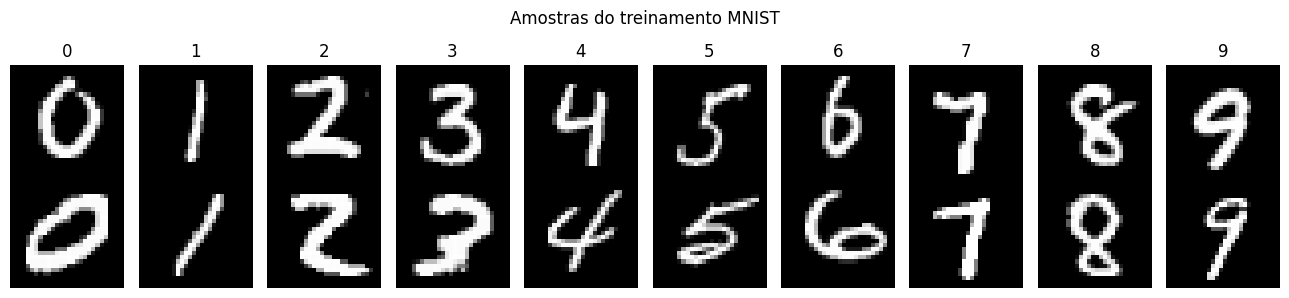

In [ ]:
(x_base, y_base), (x_teste, y_teste) = tf.keras.datasets.mnist.load_data()
x_treino, x_val, y_treino, y_val = train_test_split(
    x_base, y_base, test_size=.10, random_state=SEED, stratify=y_base
)

for nome, x, y in [
    ('Treino', x_treino, y_treino),
    ('Validação', x_val, y_val),
    ('Teste', x_teste, y_teste)
]:
    print(f'{nome:10s}: {x.shape} | rótulos: {y.shape} | pixels: {x.min()} a {x.max()}')

fig, axs = plt.subplots(2, 10, figsize=(13, 3))
rng = np.random.default_rng(SEED)
for digito in range(10):
    ids = np.flatnonzero(y_treino == digito)
    for linha, idx in enumerate(rng.choice(ids, 2, replace=False)):
        axs[linha, digito].imshow(x_treino[idx], cmap='gray')
        axs[linha, digito].axis('off')
        if linha == 0:
            axs[linha, digito].set_title(str(digito))
plt.suptitle('Amostras do treinamento MNIST')
plt.tight_layout()
plt.show()

## 5 — Variações sintéticas

As transformações simulam diferenças entre o MNIST e uma fotografia: inclinação, posição, escala, perspectiva, espessura, iluminação, desfoque, compressão e ruído.

±20° não é uma regra rígida de aceitação. É apenas a faixa de inclinações pequenas apresentada ao classificador. Rotações de 90° são tratadas pela etapa de orientação da fotografia.

10000/54000 imagens processadas
20000/54000 imagens processadas
30000/54000 imagens processadas
40000/54000 imagens processadas
50000/54000 imagens processadas
Sintéticos gerados em 14.3s: (54000, 28, 28)
Sintéticos gerados em 1.5s: (6000, 28, 28)


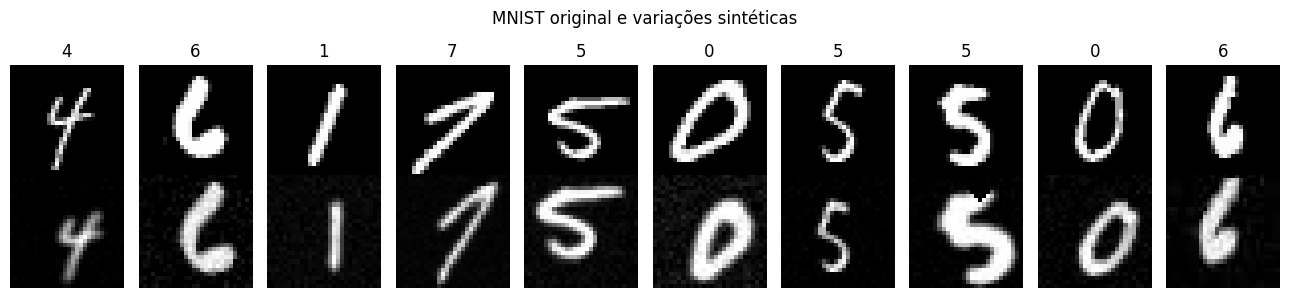

In [ ]:
def sintetizar_recorte(imagem, rng):
    img = imagem.astype(np.uint8)
    angulo = rng.uniform(-ANGULO_SINTETICO, ANGULO_SINTETICO)
    escala = rng.uniform(.80, 1.20)
    tx, ty = rng.uniform(-3.2, 3.2, size=2)

    matriz = cv2.getRotationMatrix2D((13.5, 13.5), angulo, escala)
    matriz[:, 2] += (tx, ty)
    img = cv2.warpAffine(img, matriz, (28, 28), flags=cv2.INTER_LINEAR, borderValue=0)

    if rng.random() < .45:
        deslocamento = rng.uniform(-1.6, 1.6, size=(4, 2)).astype(np.float32)
        origem = np.float32([[2, 2], [25, 2], [2, 25], [25, 25]])
        destino = origem + deslocamento
        h = cv2.getPerspectiveTransform(origem, destino)
        img = cv2.warpPerspective(img, h, (28, 28), flags=cv2.INTER_LINEAR, borderValue=0)

    espessura = rng.choice([-1, 0, 0, 0, 1])
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    if espessura == 1:
        img = cv2.dilate(img, kernel, iterations=1)
    elif espessura == -1:
        img = cv2.erode(img, kernel, iterations=1)

    if rng.random() < .45:
        img = cv2.GaussianBlur(img, (3, 3), rng.uniform(.25, 1.0))

    contraste = rng.uniform(.65, 1.35)
    brilho = rng.uniform(-12, 12)
    img = np.clip(img.astype(np.float32) * contraste + brilho, 0, 255)
    img += rng.normal(0, rng.uniform(0, 15), img.shape)
    img = np.clip(img, 0, 255).astype(np.uint8)

    if rng.random() < .20:
        qualidade = int(rng.integers(35, 90))
        ok, codificada = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, qualidade])
        if ok:
            img = cv2.imdecode(codificada, cv2.IMREAD_GRAYSCALE)

    if rng.random() < .18:
        ys, xs = np.where(img > 90)
        if len(xs):
            k = int(rng.integers(0, len(xs)))
            cv2.circle(img, (int(xs[k]), int(ys[k])), int(rng.integers(1, 3)), 0, -1)

    return img

def gerar_sinteticos(x, y, quantidade_por_imagem, seed):
    if quantidade_por_imagem <= 0:
        return np.empty((0, 28, 28), np.uint8), np.empty((0,), y.dtype)
    rng = np.random.default_rng(seed)
    total = len(x) * quantidade_por_imagem
    imagens = np.empty((total, 28, 28), dtype=np.uint8)
    rotulos = np.empty((total,), dtype=y.dtype)
    pos = 0
    inicio = time.perf_counter()
    for idx, (imagem, rotulo) in enumerate(zip(x, y)):
        for _ in range(quantidade_por_imagem):
            imagens[pos] = sintetizar_recorte(imagem, rng)
            rotulos[pos] = rotulo
            pos += 1
        if (idx + 1) % 10000 == 0:
            print(f'{idx + 1}/{len(x)} imagens processadas')
    print(f'Sintéticos gerados em {time.perf_counter() - inicio:.1f}s:', imagens.shape)
    return imagens, rotulos

x_treino_sint, y_treino_sint = gerar_sinteticos(
    x_treino, y_treino, SINTETICOS_POR_IMAGEM, SEED + 100
)
x_val_sint, y_val_sint = gerar_sinteticos(x_val, y_val, 1, SEED + 200)

x_treino_misto = np.concatenate([x_treino, x_treino_sint])
y_treino_misto = np.concatenate([y_treino, y_treino_sint])
x_val_misto = np.concatenate([x_val, x_val_sint])
y_val_misto = np.concatenate([y_val, y_val_sint])

fig, axs = plt.subplots(2, 10, figsize=(13, 3))
ids = np.random.default_rng(SEED).choice(len(x_val), 10, replace=False)
for coluna, idx in enumerate(ids):
    axs[0, coluna].imshow(x_val[idx], cmap='gray')
    axs[1, coluna].imshow(x_val_sint[idx], cmap='gray')
    axs[0, coluna].set_title(str(y_val[idx]))
    axs[0, coluna].axis('off')
    axs[1, coluna].axis('off')
axs[0, 0].set_ylabel('Original')
axs[1, 0].set_ylabel('Sintética')
plt.suptitle('MNIST original e variações sintéticas')
plt.tight_layout()
plt.show()

## 6 — Conjunto de fotografias reais

O notebook cria esta estrutura no Drive:

```text
dados_reais/
├── treino/       # ajuste opcional do classificador
│   ├── 0/ ... 9/
├── calibracao/   # seleção e calibração da rejeição
│   ├── 0/ ... 9/
└── teste/        # usado somente na avaliação final
    ├── 0/ ... 9/
```

Não copie a mesma fotografia para divisões diferentes. Fotografias semelhantes tiradas na mesma sequência devem permanecer na mesma divisão.

Meta mínima por dígito: 10 fotos em `treino`, 5 em `calibracao` e 5 em `teste`. O ideal é chegar a 30/10/10 por dígito, com diferentes pessoas, papéis, canetas, distâncias e iluminações.

In [ ]:
for divisao in ('treino', 'calibracao', 'teste'):
    for digito in range(10):
        (PASTA_DADOS_REAIS / divisao / str(digito)).mkdir(parents=True, exist_ok=True)

print('✅ Estrutura criada em:', PASTA_DADOS_REAIS)
print('Coloque cada fotografia na pasta correspondente ao dígito verdadeiro.')

✅ Estrutura criada em: /content/drive/MyDrive/DigitCheck_V3/dados_reais
Coloque cada fotografia na pasta correspondente ao dígito verdadeiro.


### 6.1 — Coletor opcional

Altere `EXECUTAR_COLETA` para `True`, escolha a divisão e informe o rótulo. A célula não abre o seletor durante “Executar tudo” enquanto permanecer `False`.

In [ ]:
EXECUTAR_COLETA = False
DIVISAO_COLETA = 'treino'   # treino, calibracao ou teste
ROTULO_COLETA = 5           # número verdadeiro da foto

if EXECUTAR_COLETA:
    if DIVISAO_COLETA not in {'treino', 'calibracao', 'teste'}:
        raise ValueError('DIVISAO_COLETA inválida.')
    if ROTULO_COLETA not in range(10):
        raise ValueError('ROTULO_COLETA deve estar entre 0 e 9.')
    enviados_coleta = files.upload()
    destino = PASTA_DADOS_REAIS / DIVISAO_COLETA / str(ROTULO_COLETA)
    for nome, conteudo in enviados_coleta.items():
        sufixo = Path(nome).suffix.lower() or '.jpg'
        nome_novo = datetime.now().strftime('%Y%m%d_%H%M%S_%f') + sufixo
        (destino / nome_novo).write_bytes(conteudo)
        print('Salva:', destino / nome_novo)
else:
    print('Coleta desativada. Mude EXECUTAR_COLETA para True quando quiser enviar fotos.')

Coleta desativada. Mude EXECUTAR_COLETA para True quando quiser enviar fotos.


## 7 — Segmentação: fotografia → recorte de 28×28

Esta é a etapa mais importante para corrigir os erros observados nas fotos reais.

- `um_digito`: seleciona um único agrupamento principal e ignora componentes extras;
- `sequencia`: tenta preservar vários componentes alinhados e continua experimental;
- o fundo local é estimado antes da binarização para reduzir sombras;
- componentes de borda, riscos longos e ruídos pequenos são penalizados;
- fragmentos próximos podem ser reunidos antes do redimensionamento.

Uma confiança alta da CNN nunca corrige uma segmentação errada. Por isso cada recorte também recebe uma nota de qualidade geométrica.

In [ ]:
EXTENSOES_IMAGEM = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}


def aplicar_rotacao(arr, angulo):
    if angulo == 0:
        return arr.copy()

    if angulo == 90:
        return cv2.rotate(arr, cv2.ROTATE_90_CLOCKWISE)

    if angulo == -90:
        return cv2.rotate(arr, cv2.ROTATE_90_COUNTERCLOCKWISE)

    if abs(angulo) == 180:
        return cv2.rotate(arr, cv2.ROTATE_180)

    altura, largura = arr.shape[:2]

    matriz = cv2.getRotationMatrix2D(
        (largura / 2, altura / 2),
        angulo,
        1.0
    )

    return cv2.warpAffine(
        arr,
        matriz,
        (largura, altura),
        borderMode=cv2.BORDER_REPLICATE
    )


def unir_caixas(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b

    x1 = min(ax, bx)
    y1 = min(ay, by)

    x2 = max(ax + aw, bx + bw)
    y2 = max(ay + ah, by + bh)

    return x1, y1, x2 - x1, y2 - y1


def distancia_caixas(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b

    gap_x = max(0, max(ax, bx) - min(ax + aw, bx + bw))
    gap_y = max(0, max(ay, by) - min(ay + ah, by + bh))

    return float(np.hypot(gap_x, gap_y))


def preparar_recorte(binario, caixa):
    x, y, w, h = caixa

    margem = max(4, round(.20 * max(w, h)))

    y0 = max(0, y - margem)
    y1 = min(binario.shape[0], y + h + margem)

    x0 = max(0, x - margem)
    x1 = min(binario.shape[1], x + w + margem)

    recorte = binario[y0:y1, x0:x1]

    pontos = cv2.findNonZero(recorte)

    if pontos is None:
        raise ValueError('Recorte vazio.')

    rx, ry, rw, rh = cv2.boundingRect(pontos)
    recorte = recorte[ry:ry + rh, rx:rx + rw]

    escala = 20.0 / max(recorte.shape)

    nova_largura = max(1, round(recorte.shape[1] * escala))
    nova_altura = max(1, round(recorte.shape[0] * escala))

    interpolacao = (
        cv2.INTER_AREA
        if escala < 1
        else cv2.INTER_CUBIC
    )

    pequeno = cv2.resize(
        recorte,
        (nova_largura, nova_altura),
        interpolation=interpolacao
    )

    tela = np.zeros((28, 28), dtype=np.uint8)

    oy = (28 - nova_altura) // 2
    ox = (28 - nova_largura) // 2

    tela[
        oy:oy + nova_altura,
        ox:ox + nova_largura
    ] = pequeno

    momentos = cv2.moments(tela)

    if momentos['m00'] > 0:
        cx = momentos['m10'] / momentos['m00']
        cy = momentos['m01'] / momentos['m00']

        matriz = np.float32([
            [1, 0, 13.5 - cx],
            [0, 1, 13.5 - cy]
        ])

        tela = cv2.warpAffine(
            tela,
            matriz,
            (28, 28),
            flags=cv2.INTER_LINEAR,
            borderValue=0
        )

    return tela


def binarizar_foto(arr):
    cinza = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    cinza = cv2.GaussianBlur(cinza, (5, 5), 0)

    fundo = cv2.GaussianBlur(
        cinza,
        (0, 0),
        sigmaX=max(15, min(cinza.shape) / 20),
        sigmaY=max(15, min(cinza.shape) / 20)
    )

    normalizada = cv2.divide(cinza, fundo, scale=255)

    _, binario_escuro = cv2.threshold(
        normalizada,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
    saturacao = hsv[..., 1]
    valor = hsv[..., 2]

    mascara_cor = (
        (saturacao >= 45) &
        (valor < 245)
    ).astype(np.uint8) * 255

    proporcao_cor = cv2.countNonZero(mascara_cor) / mascara_cor.size

    if 0.00001 <= proporcao_cor <= .10:
        binario = cv2.bitwise_or(binario_escuro, mascara_cor)
    else:
        binario = binario_escuro

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    binario = cv2.morphologyEx(
        binario,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    binario = cv2.morphologyEx(
        binario,
        cv2.MORPH_OPEN,
        np.ones((2, 2), dtype=np.uint8),
        iterations=1
    )

    return binario


def componentes_validos(binario):
    altura, largura = binario.shape
    area_total = altura * largura

    contornos, _ = cv2.findContours(
        binario,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    componentes = []

    for contorno in contornos:
        x, y, w, h = cv2.boundingRect(contorno)

        pixels = cv2.countNonZero(binario[y:y + h, x:x + w])
        densidade = pixels / max(1, w * h)
        aspecto = w / max(h, 1)

        encosta_borda = (
            x <= 2 or
            y <= 2 or
            x + w >= largura - 2 or
            y + h >= altura - 2
        )

        parece_linha = (
            h > 12 * max(w, 1) or
            w > 6 * max(h, 1)
        )

        tamanho_ruim = (
            w * h < area_total * .00015 or
            h < altura * .025 or
            h > altura * .80 or
            w > largura * .65
        )

        proporcao_ruim = not (0.06 <= aspecto <= 2.0)

        if encosta_borda and parece_linha:
            continue

        if (
            parece_linha or
            tamanho_ruim or
            proporcao_ruim or
            densidade < .012
        ):
            continue

        componentes.append({
            'caixa': (x, y, w, h),
            'pixels': pixels,
            'densidade': densidade
        })

    return componentes


def pontuar_componente(componente, forma):
    altura, largura = forma
    x, y, w, h = componente['caixa']

    tamanho = np.clip(h / max(1, .05 * altura), 0, 1)
    aspecto = w / max(h, 1)

    aspecto_ok = 1.0 if .08 <= aspecto <= 1.7 else .30

    distancia_borda = min(
        x,
        y,
        largura - (x + w),
        altura - (y + h)
    )

    borda_ok = np.clip(
        distancia_borda / max(3, .01 * min(altura, largura)),
        0,
        1
    )

    return (
        np.log1p(componente['pixels']) *
        (.55 + .45 * tamanho) *
        aspecto_ok *
        (.90 + .10 * borda_ok)
    )


def completar_caixa_principal(binario, principal):
    contornos, _ = cv2.findContours(
        binario,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    x, y, w, h = principal

    pixels_principal = cv2.countNonZero(
        binario[y:y + h, x:x + w]
    )

    candidatos = []

    for contorno in contornos:
        bx, by, bw, bh = cv2.boundingRect(contorno)

        pixels = cv2.countNonZero(
            binario[by:by + bh, bx:bx + bw]
        )

        centro_x = bx + bw / 2

        perto_horizontalmente = (
            x - 0.70 * h
            <= centro_x
            <= x + w + 0.70 * h
        )

        if not perto_horizontalmente:
            continue

        if pixels < max(15, 0.12 * pixels_principal):
            continue

        if bh < 0.25 * h:
            continue

        if bw > 3 * max(bh, 1):
            continue

        candidatos.append((bx, by, bw, bh))

    atual = principal

    for _ in range(3):
        mudou = False

        for caixa in candidatos:
            bx, by, bw, bh = caixa
            ax, ay, aw, ah = atual

            nova = unir_caixas(atual, caixa)

            if nova == atual:
                continue

            altura_ref = max(ah, bh)

            gap_x = max(
                0,
                max(ax, bx) - min(ax + aw, bx + bw)
            )

            sobreposicao_y = max(
                0,
                min(ay + ah, by + bh) - max(ay, by)
            )

            fracao_y = (
                sobreposicao_y /
                max(1, min(ah, bh))
            )

            diferenca_centro_y = abs(
                (ay + ah / 2) -
                (by + bh / 2)
            )

            aspecto_uniao = (
                nova[2] /
                max(nova[3], 1)
            )

            pertence_ao_digito = (
                gap_x <= 0.50 * altura_ref
                and (
                    fracao_y >= 0.15
                    or diferenca_centro_y <= 0.50 * altura_ref
                )
                and aspecto_uniao <= 1.30
            )

            if pertence_ao_digito:
                atual = nova
                mudou = True

        if not mudou:
            break

    return atual


def selecionar_um_digito(componentes, binario):
    if not componentes:
        return []

    principal = max(
        componentes,
        key=lambda c: pontuar_componente(c, binario.shape)
    )['caixa']

    principal = completar_caixa_principal(
        binario,
        principal
    )

    return [principal]


def unir_fragmentos_sequencia(caixas):
    caixas = sorted(caixas, key=lambda caixa: caixa[0])
    resultado = []
    indice = 0

    while indice < len(caixas):
        atual = caixas[indice]
        proximo = indice + 1

        while proximo < len(caixas):
            candidato = caixas[proximo]
            uniao = unir_caixas(atual, candidato)

            gap = distancia_caixas(atual, candidato)
            menor_area = min(
                atual[2] * atual[3],
                candidato[2] * candidato[3]
            )

            maior_area = max(
                atual[2] * atual[3],
                candidato[2] * candidato[3]
            )

            if (
                menor_area <= .40 * maior_area and
                gap <= .30 * max(atual[3], candidato[3]) and
                uniao[2] <= 1.55 * uniao[3]
            ):
                atual = uniao
                proximo += 1
            else:
                break

        resultado.append(atual)
        indice = proximo

    return resultado


def selecionar_sequencia(componentes):
    if not componentes:
        return []

    caixas = [componente['caixa'] for componente in componentes]
    caixas = unir_fragmentos_sequencia(caixas)

    alturas = np.array(
        [caixa[3] for caixa in caixas],
        dtype=float
    )

    referencia = np.median(alturas)

    caixas = [
        caixa for caixa in caixas
        if .40 * referencia <= caixa[3] <= 2.5 * referencia
    ]

    centros_y = np.array([
        y + h / 2
        for _, y, _, h in caixas
    ])

    if len(centros_y):
        linha = np.median(centros_y)

        caixas = [
            caixa for caixa in caixas
            if abs((caixa[1] + caixa[3] / 2) - linha)
            <= .85 * referencia
        ]

    return sorted(caixas, key=lambda caixa: caixa[0])


def qualidade_caixa(binario, caixa):
    x, y, w, h = caixa
    altura, largura = binario.shape

    regiao = binario[y:y + h, x:x + w]

    densidade = cv2.countNonZero(regiao) / max(1, w * h)
    aspecto = w / max(h, 1)

    tamanho = np.clip(h / max(1, .05 * altura), 0, 1)

    densidade_ok = (
        np.clip(densidade / .05, 0, 1) *
        np.clip((.80 - densidade) / .20, 0, 1)
    )

    aspecto_ok = 1.0 if .07 <= aspecto <= 1.8 else .25

    borda = min(
        x,
        y,
        largura - (x + w),
        altura - (y + h)
    )

    borda_ok = np.clip(
        borda / max(3, .01 * min(altura, largura)),
        0,
        1
    )

    return float(np.clip(
        .35 * tamanho +
        .30 * densidade_ok +
        .20 * aspecto_ok +
        .15 * borda_ok,
        0,
        1
    ))


def extrair_digitos(
    imagem,
    modo='um_digito',
    rotacao=0,
    roi=None
):
    imagem = ImageOps.exif_transpose(imagem).convert('RGB')

    arr = np.asarray(imagem)
    arr = aplicar_rotacao(arr, rotacao)

    if roi is not None:
        x, y, w, h = map(int, roi)
        arr = arr[y:y + h, x:x + w]

    if not arr.size:
        raise ValueError('A região de interesse ficou vazia.')

    if max(arr.shape[:2]) > 1600:
        escala = 1600 / max(arr.shape[:2])

        arr = cv2.resize(
            arr,
            None,
            fx=escala,
            fy=escala,
            interpolation=cv2.INTER_AREA
        )

    binario = binarizar_foto(arr)
    componentes = componentes_validos(binario)

    if modo == 'um_digito':
        caixas = selecionar_um_digito(componentes, binario)

    elif modo == 'sequencia':
        caixas = selecionar_sequencia(componentes)

    else:
        raise ValueError(
            "modo deve ser 'um_digito' ou 'sequencia'."
        )

    if not caixas:
        raise ValueError('Nenhum candidato válido foi encontrado.')

    recortes = [
        preparar_recorte(binario, caixa)
        for caixa in caixas
    ]

    qualidades = [
        qualidade_caixa(binario, caixa)
        for caixa in caixas
    ]

    return {
        'original': arr,
        'binario': binario,
        'caixas': caixas,
        'recortes': recortes,
        'qualidades': qualidades,
        'rotacao': rotacao,
        'modo': modo
    }

In [ ]:
# Correção experimental:
# 1. preserva a seleção correta do 5 em vez do círculo da borda;
# 2. incorpora pequenos traços horizontais do 7;
# 3. mantém a união dos fragmentos do 4.


def completar_caixa_principal(binario, principal):
    contornos, _ = cv2.findContours(
        binario,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    x, y, w, h = principal

    pixels_principal = cv2.countNonZero(
        binario[y:y + h, x:x + w]
    )

    candidatos = []

    for contorno in contornos:
        bx, by, bw, bh = cv2.boundingRect(contorno)

        caixa = (bx, by, bw, bh)

        pixels = cv2.countNonZero(
            binario[
                by:by + bh,
                bx:bx + bw
            ]
        )

        centro_x = bx + bw / 2
        centro_y = by + bh / 2

        perto_horizontalmente = (
            x - 0.70 * h
            <= centro_x
            <= x + w + 0.70 * h
        )

        if not perto_horizontalmente:
            continue

        # Detecta barras horizontais próximas da parte superior
        # ou central do dígito. Isso inclui a barra superior
        # e o pequeno corte central do 7.
        fragmento_horizontal = (
            bw >= 1.25 * max(bh, 1)
            and bw >= max(3, 0.10 * h)
            and bw <= 1.10 * h
            and bh <= 0.35 * h
            and y - 0.25 * h
            <= centro_y
            <= y + 0.75 * h
        )

        if fragmento_horizontal:
            pixels_minimos = max(
                5,
                0.04 * pixels_principal
            )
        else:
            pixels_minimos = max(
                15,
                0.12 * pixels_principal
            )

        if pixels < pixels_minimos:
            continue

        # Componentes muito baixos normalmente são ruído,
        # exceto quando formam uma barra horizontal válida.
        if (
            bh < 0.25 * h
            and not fragmento_horizontal
        ):
            continue

        # Componentes excessivamente largos também são
        # descartados, salvo a exceção controlada acima.
        if (
            bw > 3 * max(bh, 1)
            and not fragmento_horizontal
        ):
            continue

        candidatos.append({
            'caixa': caixa,
            'horizontal': fragmento_horizontal
        })

    atual = principal

    # Limite fixo para impedir ciclos infinitos
    for _ in range(3):
        mudou = False

        for candidato in candidatos:
            caixa = candidato['caixa']
            horizontal = candidato['horizontal']

            bx, by, bw, bh = caixa
            ax, ay, aw, ah = atual

            nova = unir_caixas(
                atual,
                caixa
            )

            if nova == atual:
                continue

            altura_ref = max(
                ah,
                bh
            )

            gap_x = max(
                0,
                max(ax, bx) -
                min(ax + aw, bx + bw)
            )

            sobreposicao_y = max(
                0,
                min(ay + ah, by + bh) -
                max(ay, by)
            )

            fracao_y = (
                sobreposicao_y /
                max(1, min(ah, bh))
            )

            diferenca_centro_y = abs(
                (ay + ah / 2) -
                (by + bh / 2)
            )

            aspecto_uniao = (
                nova[2] /
                max(nova[3], 1)
            )

            distancia = distancia_caixas(
                atual,
                caixa
            )

            if horizontal:
                pertence_ao_digito = (
                    distancia <= 0.35 * altura_ref
                    and gap_x <= 0.35 * altura_ref
                    and aspecto_uniao <= 1.30
                )

            else:
                pertence_ao_digito = (
                    gap_x <= 0.50 * altura_ref
                    and (
                        fracao_y >= 0.15
                        or diferenca_centro_y
                        <= 0.50 * altura_ref
                    )
                    and aspecto_uniao <= 1.30
                )

            if pertence_ao_digito:
                atual = nova
                mudou = True

        if not mudou:
            break

    return atual


def selecionar_um_digito(componentes, binario):
    if not componentes:
        return []

    altura, largura = binario.shape

    margem_borda = max(
        3,
        round(
            0.01 *
            min(altura, largura)
        )
    )

    candidatos_internos = []

    for componente in componentes:
        x, y, w, h = componente['caixa']

        encosta_borda = (
            x <= margem_borda
            or y <= margem_borda
            or x + w >= largura - margem_borda
            or y + h >= altura - margem_borda
        )

        if not encosta_borda:
            candidatos_internos.append(
                componente
            )

    # Componentes internos têm prioridade.
    # A borda continua disponível como fallback.
    candidatos = (
        candidatos_internos
        if candidatos_internos
        else componentes
    )

    principal = max(
        candidatos,
        key=lambda componente:
            pontuar_componente(
                componente,
                binario.shape
            )
    )['caixa']

    principal = completar_caixa_principal(
        binario,
        principal
    )

    return [principal]


print(
    '✅ Correção experimental carregada: '
    'fragmentos horizontais + proteção de borda.'
)

✅ Correção experimental carregada: fragmentos horizontais + proteção de borda.


In [ ]:
# ============================================================
# SEGMENTAÇÃO UNIFICADA: UM OU VÁRIOS DÍGITOS
#
# O modo "sequencia" agora aceita uma sequência com um ou mais
# elementos. A seleção original de sequência continua sendo a
# primeira tentativa. Quando ela não encontra candidatos, usamos
# internamente a seleção estável de um dígito como fallback.
#
# A recuperação de traços fracos é aplicada separadamente em
# cada caixa, com limites definidos pelos dígitos vizinhos.
# ============================================================


def binarizar_detalhes(arr):
    cinza = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

    cinza = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    ).apply(cinza)

    cinza = cv2.GaussianBlur(
        cinza,
        (5, 5),
        0
    )

    detalhes = cv2.adaptiveThreshold(
        cinza,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        12
    )

    quantidade, rotulos, estatisticas, _ = (
        cv2.connectedComponentsWithStats(
            detalhes,
            connectivity=8
        )
    )

    area_minima = max(
        12,
        round(detalhes.size * .00001)
    )

    detalhes_limpos = np.zeros_like(detalhes)

    for indice in range(1, quantidade):
        area = estatisticas[
            indice,
            cv2.CC_STAT_AREA
        ]

        if area >= area_minima:
            detalhes_limpos[
                rotulos == indice
            ] = 255

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    return cv2.morphologyEx(
        detalhes_limpos,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )


def calcular_limites_vizinhos(caixas, largura_imagem):
    caixas = sorted(
        caixas,
        key=lambda caixa: caixa[0]
    )

    limites = []

    for indice, caixa in enumerate(caixas):
        x, _, w, _ = caixa

        if indice == 0:
            limite_esquerdo = 0
        else:
            anterior = caixas[indice - 1]
            fim_anterior = anterior[0] + anterior[2]

            limite_esquerdo = round(
                (fim_anterior + x) / 2
            )

        if indice == len(caixas) - 1:
            limite_direito = largura_imagem
        else:
            proxima = caixas[indice + 1]
            fim_atual = x + w

            limite_direito = round(
                (fim_atual + proxima[0]) / 2
            )

        limite_esquerdo = min(
            limite_esquerdo,
            x
        )

        limite_direito = max(
            limite_direito,
            x + w
        )

        limites.append((
            max(0, limite_esquerdo),
            min(largura_imagem, limite_direito)
        ))

    return caixas, limites


def recuperar_tracos_do_digito(
    binario_limpo,
    binario_detalhe,
    caixa,
    limite_esquerdo=0,
    limite_direito=None
):
    x, y, w, h = map(int, caixa)

    altura_imagem, largura_imagem = (
        binario_limpo.shape
    )

    if limite_direito is None:
        limite_direito = largura_imagem

    margem_x = max(4, round(.45 * h))
    margem_y = max(3, round(.25 * h))

    x0 = max(
        0,
        int(limite_esquerdo),
        x - margem_x
    )

    x1 = min(
        largura_imagem,
        int(limite_direito),
        x + w + margem_x
    )

    y0 = max(0, y - margem_y)
    y1 = min(
        altura_imagem,
        y + h + margem_y
    )

    if x1 <= x0 or y1 <= y0:
        mascara = np.zeros_like(binario_limpo)
        mascara[y:y + h, x:x + w] = binario_limpo[
            y:y + h,
            x:x + w
        ]
        return mascara, caixa

    detalhe_local = binario_detalhe[
        y0:y1,
        x0:x1
    ].copy()

    ancora = np.zeros_like(detalhe_local)

    ax0 = x - x0
    ay0 = y - y0
    ax1 = ax0 + w
    ay1 = ay0 + h

    ancora[
        ay0:ay1,
        ax0:ax1
    ] = binario_limpo[
        y:y + h,
        x:x + w
    ]

    raio = max(1, round(.04 * h))

    kernel_ancora = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (2 * raio + 1, 2 * raio + 1)
    )

    ancora_expandida = cv2.dilate(
        ancora,
        kernel_ancora,
        iterations=1
    )

    quantidade, rotulos, estatisticas, _ = (
        cv2.connectedComponentsWithStats(
            detalhe_local,
            connectivity=8
        )
    )

    recuperados = np.zeros_like(detalhe_local)

    for indice in range(1, quantidade):
        componente = (
            rotulos == indice
        ).astype(np.uint8) * 255

        toca_digito = cv2.countNonZero(
            cv2.bitwise_and(
                componente,
                ancora_expandida
            )
        ) > 0

        if not toca_digito:
            continue

        largura_componente = estatisticas[
            indice,
            cv2.CC_STAT_WIDTH
        ]

        altura_componente = estatisticas[
            indice,
            cv2.CC_STAT_HEIGHT
        ]

        area_componente = estatisticas[
            indice,
            cv2.CC_STAT_AREA
        ]

        componente_exagerado = (
            largura_componente > 1.60 * h
            or altura_componente > 1.60 * h
            or area_componente > .65 * detalhe_local.size
        )

        if componente_exagerado:
            continue

        recuperados = cv2.bitwise_or(
            recuperados,
            componente
        )

    mascara_local = cv2.bitwise_or(
        ancora,
        recuperados
    )

    pontos = cv2.findNonZero(mascara_local)

    if pontos is None:
        mascara = np.zeros_like(binario_limpo)
        mascara[y:y + h, x:x + w] = binario_limpo[
            y:y + h,
            x:x + w
        ]
        return mascara, caixa

    rx, ry, rw, rh = cv2.boundingRect(pontos)

    caixa_recuperada = (
        x0 + rx,
        y0 + ry,
        rw,
        rh
    )

    mascara_modelo = np.zeros_like(
        binario_limpo
    )

    mascara_modelo[
        y0:y1,
        x0:x1
    ] = mascara_local

    return mascara_modelo, caixa_recuperada


def caixa_unica_suspeita(caixa, forma):
    altura, largura = forma
    x, y, w, h = caixa

    margem_borda = max(
        3,
        round(.01 * min(altura, largura))
    )

    encosta_borda = (
        x <= margem_borda
        or y <= margem_borda
        or x + w >= largura - margem_borda
        or y + h >= altura - margem_borda
    )

    grande_demais = (
        h > .35 * altura
        or w > .35 * largura
    )

    return encosta_borda or grande_demais


def extrair_digitos(
    imagem,
    modo='sequencia',
    rotacao=0,
    roi=None
):
    imagem = ImageOps.exif_transpose(
        imagem
    ).convert('RGB')

    arr = np.asarray(imagem)
    arr = aplicar_rotacao(arr, rotacao)

    if roi is not None:
        x, y, w, h = map(int, roi)
        arr = arr[y:y + h, x:x + w]

    if not arr.size:
        raise ValueError(
            'A região de interesse ficou vazia.'
        )

    if max(arr.shape[:2]) > 1600:
        escala = 1600 / max(arr.shape[:2])

        arr = cv2.resize(
            arr,
            None,
            fx=escala,
            fy=escala,
            interpolation=cv2.INTER_AREA
        )

    binario_limpo = binarizar_foto(arr)
    componentes = componentes_validos(
        binario_limpo
    )

    if not componentes:
        raise ValueError(
            'Nenhum componente plausível foi encontrado.'
        )

    if modo == 'um_digito':
        caixas = selecionar_um_digito(
            componentes,
            binario_limpo
        )
        origem_selecao = 'um_digito'

    elif modo in ('sequencia', 'simbolos'):
        caixas = selecionar_sequencia(
            componentes
        )
        origem_selecao = 'linha_principal'

        precisa_fallback = not caixas

        if len(caixas) == 1:
            precisa_fallback = (
                precisa_fallback
                or caixa_unica_suspeita(
                    caixas[0],
                    binario_limpo.shape
                )
            )

        if precisa_fallback:
            caixas = selecionar_um_digito(
                componentes,
                binario_limpo
            )
            origem_selecao = 'fallback_candidato_unico'

    else:
        raise ValueError(
            "modo deve ser 'um_digito', "
            "'sequencia' ou 'simbolos'."
        )

    if not caixas:
        raise ValueError(
            'Nenhum candidato válido foi encontrado.'
        )

    caixas, limites = calcular_limites_vizinhos(
        caixas,
        binario_limpo.shape[1]
    )

    binario_detalhe = binarizar_detalhes(arr)
    binario_visual = binario_limpo.copy()

    caixas_recuperadas = []
    recortes = []
    qualidades = []

    for caixa, limites_caixa in zip(
        caixas,
        limites
    ):
        limite_esquerdo, limite_direito = (
            limites_caixa
        )

        mascara_modelo, caixa_recuperada = (
            recuperar_tracos_do_digito(
                binario_limpo,
                binario_detalhe,
                caixa,
                limite_esquerdo,
                limite_direito
            )
        )

        recorte = preparar_recorte(
            mascara_modelo,
            caixa_recuperada
        )

        caixas_recuperadas.append(
            caixa_recuperada
        )

        recortes.append(recorte)

        qualidades.append(
            qualidade_caixa(
                binario_limpo,
                caixa
            )
        )

        binario_visual = cv2.bitwise_or(
            binario_visual,
            mascara_modelo
        )

    return {
        'original': arr,
        'binario': binario_visual,
        'binario_limpo': binario_limpo,
        'binario_detalhe': binario_detalhe,
        'caixas': caixas_recuperadas,
        'recortes': recortes,
        'qualidades': qualidades,
        'rotacao': rotacao,
        'modo': modo,
        'origem_selecao': origem_selecao
    }


print(
    '✅ Segmentação unificada carregada: '
    'sequência com um ou mais dígitos + recuperação local.'
)


✅ Segmentação unificada carregada: sequência com um ou mais dígitos + recuperação local.


### 7.1 — Segmentação unificada de um ou mais dígitos

O modo `sequencia` agora também aceita uma única caixa. Ele preserva a seleção alinhada quando há vários dígitos, usa a seleção estável de um candidato como fallback interno e recupera detalhes fracos separadamente em cada caixa, respeitando os limites entre vizinhos.


## 8 — Carregar os recortes reais sem misturar as divisões

Para treinamento e calibração, as fotos devem estar em pé depois da correção EXIF. Se uma câmera gravar a orientação incorretamente, ajuste `ROTACAO_DADOS_REAIS` e mantenha o mesmo padrão em toda a pasta.

A célula registra quantos arquivos falharam na segmentação. Esses erros não são silenciosamente transformados em acertos do classificador.

In [ ]:
ROTACAO_DADOS_REAIS = 0

def caminhos_rotulados(divisao):
    itens = []
    for digito in range(10):
        pasta = PASTA_DADOS_REAIS / divisao / str(digito)
        if not pasta.exists():
            continue
        for caminho in sorted(pasta.iterdir()):
            if caminho.suffix.lower() in EXTENSOES_IMAGEM:
                itens.append((caminho, digito))
    return itens

def carregar_recortes_reais(divisao):
    recortes, rotulos, registros = [], [], []
    for caminho, rotulo in caminhos_rotulados(divisao):
        try:
            resultado = extrair_digitos(
                Image.open(caminho), modo='um_digito', rotacao=ROTACAO_DADOS_REAIS
            )
            recortes.append(resultado['recortes'][0])
            rotulos.append(rotulo)
            registros.append({
                'arquivo': str(caminho), 'rotulo': rotulo,
                'segmentado': True, 'qualidade': resultado['qualidades'][0], 'erro': ''
            })
        except Exception as erro:
            registros.append({
                'arquivo': str(caminho), 'rotulo': rotulo,
                'segmentado': False, 'qualidade': 0.0, 'erro': str(erro)
            })
    x = np.asarray(recortes, dtype=np.uint8) if recortes else np.empty((0, 28, 28), np.uint8)
    y = np.asarray(rotulos, dtype=np.int64)
    return x, y, pd.DataFrame(registros)

x_real_treino, y_real_treino, log_real_treino = carregar_recortes_reais('treino')
x_real_cal, y_real_cal, log_real_cal = carregar_recortes_reais('calibracao')

resumo_reais = pd.DataFrame([
    {'divisao': 'treino', 'arquivos': len(log_real_treino), 'segmentados': len(x_real_treino), 'classes': len(np.unique(y_real_treino))},
    {'divisao': 'calibracao', 'arquivos': len(log_real_cal), 'segmentados': len(x_real_cal), 'classes': len(np.unique(y_real_cal))}
])
display(resumo_reais)
log_real_treino.to_csv(PASTA / 'segmentacao_real_treino.csv', index=False)
log_real_cal.to_csv(PASTA / 'segmentacao_real_calibracao.csv', index=False)

,divisao,arquivos,segmentados,classes
0,treino,0,0,0
1,calibracao,0,0,0


## 9 — Três experimentos controlados

Os três nomes não significam três conjuntos de teste. São três treinamentos usados para descobrir de onde vem a melhoria:

1. **baseline:** arquitetura compacta com MNIST;
2. **compacto sintético:** mesma ideia de arquitetura, agora com dados sintéticos;
3. **espacial sintético:** dados sintéticos e arquitetura que preserva mais informação espacial.

Isso constitui uma comparação por ablação: cada experimento altera uma parte importante do sistema.

In [ ]:
def aumento_online(forte=False, incluir_zoom=True):
    graus = 14 if forte else 9
    camadas = [
        tf.keras.layers.RandomTranslation(
            .08 if forte else .04, .08 if forte else .04,
            fill_mode='constant', seed=SEED
        ),
        tf.keras.layers.RandomRotation(
            graus / 360.0, fill_mode='constant', seed=SEED + 1
        )
    ]
    if incluir_zoom:
        camadas.append(tf.keras.layers.RandomZoom(
            .08 if forte else .04, fill_mode='constant', seed=SEED + 2
        ))
    return camadas

def construir_compacto(forte=False, incluir_zoom=True):
    return tf.keras.Sequential([
        tf.keras.layers.Input((28, 28, 1), name='imagem_0_255'),
        tf.keras.layers.Rescaling(1 / 255),
        *aumento_online(forte, incluir_zoom),
        tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(.20),
        tf.keras.layers.Dense(10, activation='softmax', name='digito')
    ], name='DigitCheck_Compacto')

def construir_espacial():
    return tf.keras.Sequential([
        tf.keras.layers.Input((28, 28, 1), name='imagem_0_255'),
        tf.keras.layers.Rescaling(1 / 255),
        *aumento_online(False),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(.15),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(.20),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(96, activation='relu'),
        tf.keras.layers.Dropout(.30),
        tf.keras.layers.Dense(10, activation='softmax', name='digito')
    ], name='DigitCheck_Espacial')

EXPERIMENTOS = {
    '01_baseline': {
        'construtor': lambda: construir_compacto(True, incluir_zoom=False),
        'x': x_treino, 'y': y_treino, 'dados': 'MNIST original'
    },
    '02_compacto_sintetico': {
        'construtor': lambda: construir_compacto(False),
        'x': x_treino_misto, 'y': y_treino_misto, 'dados': 'MNIST + sintéticos'
    },
    '03_espacial_sintetico': {
        'construtor': construir_espacial,
        'x': x_treino_misto, 'y': y_treino_misto, 'dados': 'MNIST + sintéticos'
    }
}

for nome, exp in EXPERIMENTOS.items():
    modelo_temp = exp['construtor']()
    print(nome, '|', exp['dados'], '| parâmetros:', f'{modelo_temp.count_params():,}')
    del modelo_temp

01_baseline | MNIST original | parâmetros: 25,706
02_compacto_sintetico | MNIST + sintéticos | parâmetros: 25,706
03_espacial_sintetico | MNIST + sintéticos | parâmetros: 367,498


## 10 — Treinamento com teto de 40 épocas

O melhor checkpoint é salvo separadamente. O treinamento pode terminar antes da época 40 quando não houver melhoria significativa por sete épocas.

In [ ]:
registros = []

for nome, exp in EXPERIMENTOS.items():
    pasta_exp = PASTA / 'experimentos' / nome
    pasta_exp.mkdir(parents=True, exist_ok=True)
    caminho_modelo = pasta_exp / 'melhor.keras'
    caminho_historico = pasta_exp / 'historico.csv'
    caminho_resumo = pasta_exp / 'resumo.json'

    if caminho_modelo.exists() and caminho_resumo.exists():
        print('♻️ Reutilizando:', nome)
        registros.append(json.loads(caminho_resumo.read_text(encoding='utf-8')))
        continue

    print('\n🏋️ Treinando:', nome)
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    modelo = exp['construtor']()
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            str(caminho_modelo), monitor='val_accuracy', mode='max',
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.CSVLogger(str(caminho_historico)),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', mode='min', factor=.5, patience=2,
            min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', mode='max', patience=PACIENCIA,
            min_delta=.0002, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.TerminateOnNaN()
    ]
    inicio = time.perf_counter()
    modelo.fit(
        exp['x'][..., None], exp['y'],
        validation_data=(x_val_misto[..., None], y_val_misto),
        epochs=EPOCAS_MAXIMAS, batch_size=BATCH,
        callbacks=callbacks, verbose=2, shuffle=True
    )
    segundos = time.perf_counter() - inicio
    historico = pd.read_csv(caminho_historico)
    melhor = int(historico.val_accuracy.idxmax())
    registro = {
        'experimento': nome,
        'dados': exp['dados'],
        'melhor_epoca': int(historico.loc[melhor, 'epoch']) + 1,
        'melhor_val_accuracy_mista': float(historico.loc[melhor, 'val_accuracy']),
        'epocas_executadas': len(historico),
        'treinamento_segundos': segundos,
        'modelo_sha256': sha256(caminho_modelo)
    }
    salvar_json(caminho_resumo, registro)
    registros.append(registro)

display(pd.DataFrame(registros))


🏋️ Treinando: 01_baseline
Epoch 1/40

Epoch 1: val_accuracy improved from None to 0.65058, saving model to /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/experimentos/01_baseline/melhor.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/experimentos/01_baseline/melhor.keras
422/422 - 11s - 26ms/step - accuracy: 0.4399 - loss: 1.5151 - val_accuracy: 0.6506 - val_loss: 1.0693 - learning_rate: 0.0010
Epoch 2/40

Epoch 2: val_accuracy improved from 0.65058 to 0.74542, saving model to /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/experimentos/01_baseline/melhor.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/experimentos/01_baseline/melhor.keras
422/422 - 3s - 8ms/step - accuracy: 0.7741 - loss: 0.6890 - val_accuracy: 0.7454 - val_loss: 0.8201 - learning_rate: 0.0010
Epoch 3/40

Epoch 3: val_accuracy improved from 0.74542 

,experimento,dados,melhor_epoca,melhor_val_accuracy_mista,epocas_executadas,treinamento_segundos,modelo_sha256
0,01_baseline,MNIST original,27,0.948167,34,140.923584,421e45b58dda3b0fce77d2e08d2e5812eb1eccfaa6538f...
1,02_compacto_sintetico,MNIST + sintéticos,32,0.978750,39,296.173740,c7b10d0bc2be312859c40ddb7336e45f2c3079a1099343...
2,03_espacial_sintetico,MNIST + sintéticos,18,0.989167,21,329.694018,346945df1a808276b582afa21453775aa51a3eaad1de92...


### 10.1 — Curvas de treinamento

As curvas permitem verificar se aumentar o teto de épocas realmente ajudou. Uma linha que continua melhorando até o final sugere testar um teto maior; perda de validação subindo enquanto a de treino cai sugere sobreajuste.

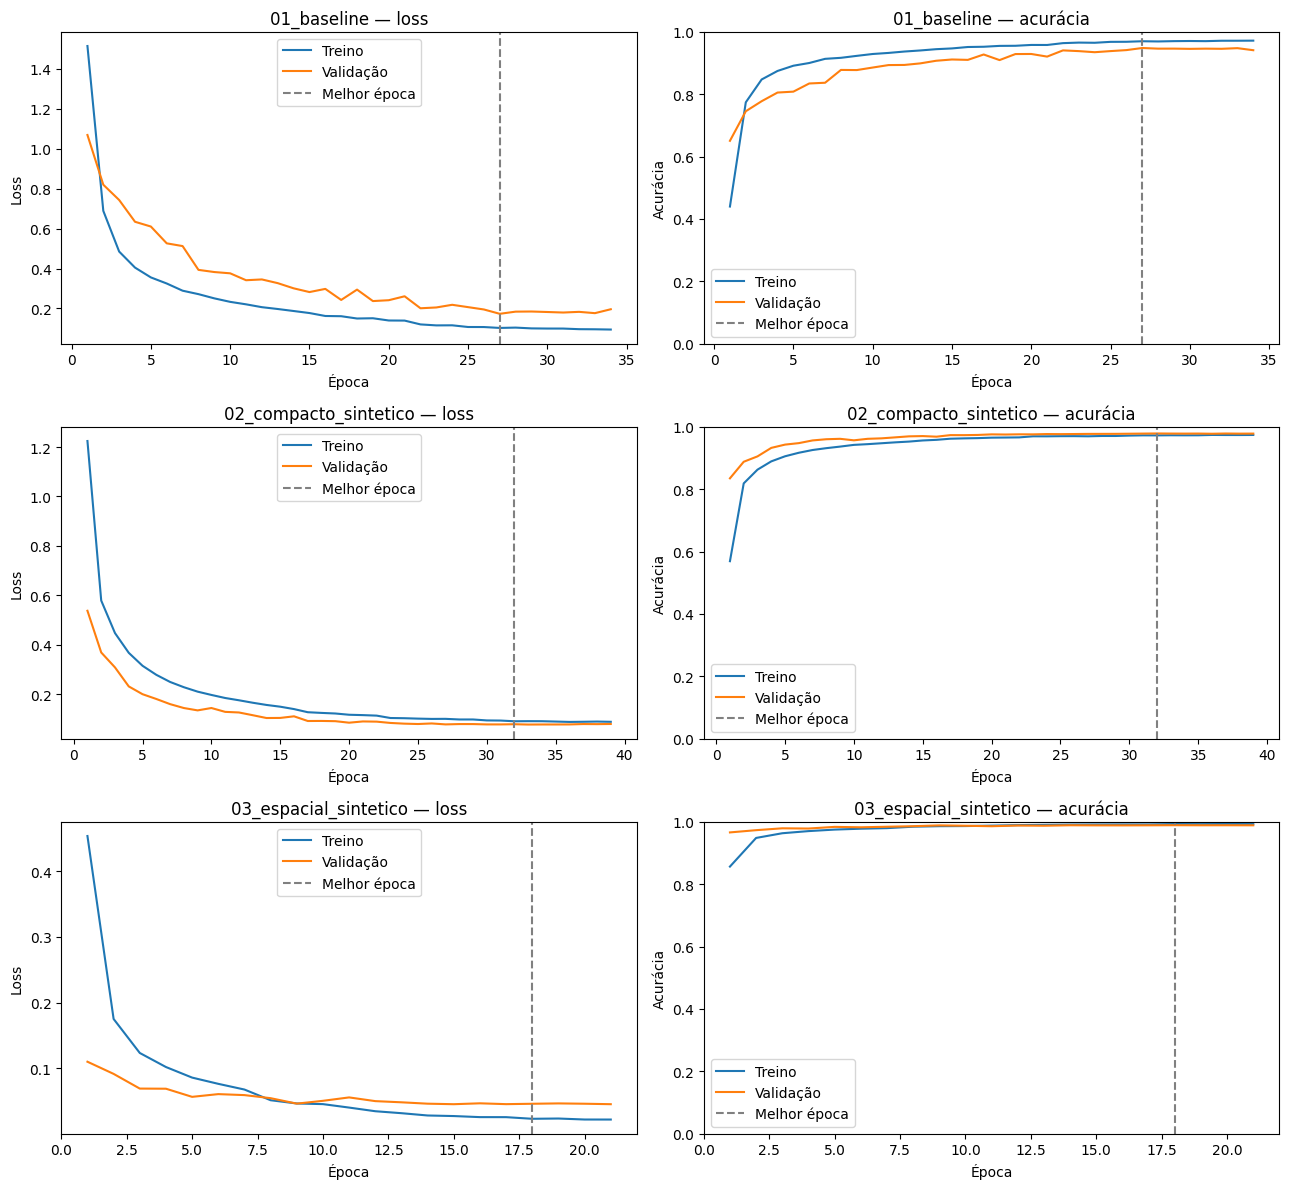

In [ ]:
fig, axs = plt.subplots(len(EXPERIMENTOS), 2, figsize=(13, 4 * len(EXPERIMENTOS)))
for linha, nome in enumerate(EXPERIMENTOS):
    hist = pd.read_csv(PASTA / 'experimentos' / nome / 'historico.csv')
    epocas = hist['epoch'] + 1
    melhor_epoca = int(hist.loc[hist.val_accuracy.idxmax(), 'epoch']) + 1

    axs[linha, 0].plot(epocas, hist.loss, label='Treino')
    axs[linha, 0].plot(epocas, hist.val_loss, label='Validação')
    axs[linha, 0].axvline(melhor_epoca, ls='--', color='gray', label='Melhor época')
    axs[linha, 0].set(title=f'{nome} — loss', xlabel='Época', ylabel='Loss')
    axs[linha, 0].legend()

    axs[linha, 1].plot(epocas, hist.accuracy, label='Treino')
    axs[linha, 1].plot(epocas, hist.val_accuracy, label='Validação')
    axs[linha, 1].axvline(melhor_epoca, ls='--', color='gray', label='Melhor época')
    axs[linha, 1].set(title=f'{nome} — acurácia', xlabel='Época', ylabel='Acurácia', ylim=(0, 1))
    axs[linha, 1].legend()

plt.tight_layout()
plt.savefig(PASTA / 'curvas_treinamento.png', dpi=150)
plt.show()

## 11 — Comparar e selecionar o modelo

Quando houver pelo menos 30 recortes reais de calibração distribuídos em cinco classes, a seleção considera também esse domínio. Caso contrário, usa somente as validações MNIST e sintética e registra essa limitação.

O conjunto `teste` continua intocado.

In [ ]:
comparacao = []
usar_real_na_selecao = len(x_real_cal) >= 30 and len(np.unique(y_real_cal)) >= 5

for nome in EXPERIMENTOS:
    caminho = PASTA / 'experimentos' / nome / 'melhor.keras'
    modelo = tf.keras.models.load_model(caminho, compile=False)
    p_mnist = modelo.predict(x_val[..., None], batch_size=256, verbose=0)
    p_sint = modelo.predict(x_val_sint[..., None], batch_size=256, verbose=0)
    acc_mnist = float((p_mnist.argmax(1) == y_val).mean())
    acc_sint = float((p_sint.argmax(1) == y_val_sint).mean())

    if usar_real_na_selecao:
        p_real = modelo.predict(x_real_cal[..., None], batch_size=256, verbose=0)
        acc_real = float((p_real.argmax(1) == y_real_cal).mean())
        score = .25 * acc_mnist + .35 * acc_sint + .40 * acc_real
        criterio = '0.25*val_mnist + 0.35*val_sintetica + 0.40*calibracao_real'
    else:
        acc_real = np.nan
        score = .40 * acc_mnist + .60 * acc_sint
        criterio = '0.40*val_mnist + 0.60*val_sintetica'

    comparacao.append({
        'experimento': nome,
        'acc_val_mnist': acc_mnist,
        'acc_val_sintetica': acc_sint,
        'acc_calibracao_real': acc_real,
        'score_selecao': score,
        'parametros': int(modelo.count_params()),
        'modelo_sha256': sha256(caminho)
    })

tabela_comparacao = pd.DataFrame(comparacao).sort_values(
    ['score_selecao', 'acc_val_sintetica', 'acc_val_mnist'], ascending=False
).reset_index(drop=True)
display(tabela_comparacao.style.format({
    'acc_val_mnist': '{:.4%}',
    'acc_val_sintetica': '{:.4%}',
    'acc_calibracao_real': lambda v: '—' if pd.isna(v) else f'{v:.4%}',
    'score_selecao': '{:.4%}'
}))

vencedor = tabela_comparacao.iloc[0]
nome_vencedor = vencedor['experimento']
caminho_vencedor = PASTA / 'experimentos' / nome_vencedor / 'melhor.keras'
MODELO_BASE_SELECIONADO = PASTA / 'modelo_base_selecionado.keras'
shutil.copy2(caminho_vencedor, MODELO_BASE_SELECIONADO)
modelo_final = tf.keras.models.load_model(MODELO_BASE_SELECIONADO, compile=False)

tabela_comparacao.to_csv(PASTA / 'comparacao_modelos.csv', index=False)
salvar_json(PASTA / 'selecao.json', {
    'experimento_vencedor': nome_vencedor,
    'criterio': criterio,
    'score_selecao': float(vencedor['score_selecao']),
    'usou_calibracao_real': bool(usar_real_na_selecao),
    'modelo_sha256': sha256(MODELO_BASE_SELECIONADO)
})
print('✅ Vencedor:', nome_vencedor)
print('Critério:', criterio)

,experimento,acc_val_mnist,acc_val_sintetica,acc_calibracao_real,score_selecao,parametros,modelo_sha256
0,03_espacial_sintetico,99.3833%,98.4500%,—,98.8233%,367498,346945df1a808276b582afa21453775aa51a3eaad1de9244cb6aa94d7a608fa7
1,02_compacto_sintetico,98.6667%,97.0833%,—,97.7167%,25706,c7b10d0bc2be312859c40ddb7336e45f2c3079a1099343cde5f98f9abd992673
2,01_baseline,97.8833%,91.7500%,—,94.2033%,25706,421e45b58dda3b0fce77d2e08d2e5812eb1eccfaa6538fcc634f68d6a177be5a


✅ Vencedor: 03_espacial_sintetico
Critério: 0.40*val_mnist + 0.60*val_sintetica


## 12 — Ajuste opcional com fotografias reais

Se houver pelo menos 50 recortes de treino e cinco classes, somente as camadas densas são ajustadas com taxa de aprendizado baixa. A calibração decide se o ajuste é mantido. O teste real continua sem uso.

Com poucas fotos, o notebook conserva o modelo sintético para evitar sobreajuste.

In [ ]:
MODELO_FINAL = PASTA / 'melhor_modelo.keras'
ajuste_real_aplicado = False

if AJUSTAR_COM_FOTOS_REAIS and len(x_real_treino) >= 50 and len(np.unique(y_real_treino)) >= 5 and len(x_real_cal) >= 20:
    print('🔧 Ajustando as camadas densas com fotos reais...')
    for camada in modelo_final.layers:
        camada.trainable = isinstance(camada, tf.keras.layers.Dense)

    modelo_final.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    caminho_ajustado = PASTA / 'modelo_ajustado_real.keras'
    modelo_final.fit(
        x_real_treino[..., None], y_real_treino,
        validation_data=(x_real_cal[..., None], y_real_cal),
        epochs=12, batch_size=min(32, len(x_real_treino)), shuffle=True, verbose=2,
        callbacks=[
            tf.keras.callbacks.ModelCheckpoint(
                str(caminho_ajustado), monitor='val_accuracy', mode='max',
                save_best_only=True, verbose=1
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', mode='max', patience=4,
                restore_best_weights=True, verbose=1
            )
        ]
    )
    candidato = tf.keras.models.load_model(caminho_ajustado, compile=False)
    base = tf.keras.models.load_model(MODELO_BASE_SELECIONADO, compile=False)
    acc_real_base = float((base.predict(x_real_cal[..., None], verbose=0).argmax(1) == y_real_cal).mean())
    acc_real_ajustada = float((candidato.predict(x_real_cal[..., None], verbose=0).argmax(1) == y_real_cal).mean())
    acc_sint_base = float((base.predict(x_val_sint[..., None], batch_size=256, verbose=0).argmax(1) == y_val_sint).mean())
    acc_sint_ajustada = float((candidato.predict(x_val_sint[..., None], batch_size=256, verbose=0).argmax(1) == y_val_sint).mean())

    if acc_real_ajustada >= acc_real_base and acc_sint_ajustada >= acc_sint_base - .005:
        shutil.copy2(caminho_ajustado, MODELO_FINAL)
        modelo_final = candidato
        ajuste_real_aplicado = True
    else:
        shutil.copy2(MODELO_BASE_SELECIONADO, MODELO_FINAL)
        modelo_final = base

    print('Calibração real — base:', f'{acc_real_base:.2%}', '| ajustada:', f'{acc_real_ajustada:.2%}')
    print('Validação sintética — base:', f'{acc_sint_base:.2%}', '| ajustada:', f'{acc_sint_ajustada:.2%}')
else:
    shutil.copy2(MODELO_BASE_SELECIONADO, MODELO_FINAL)
    modelo_final = tf.keras.models.load_model(MODELO_FINAL, compile=False)
    print('Ajuste real não executado: ainda não há dados suficientes ou a opção está desativada.')

salvar_json(PASTA / 'ajuste_real.json', {
    'aplicado': ajuste_real_aplicado,
    'n_treino_real': int(len(x_real_treino)),
    'n_calibracao_real': int(len(x_real_cal)),
    'modelo_final_sha256': sha256(MODELO_FINAL)
})
print('✅ Modelo final:', MODELO_FINAL)

Ajuste real não executado: ainda não há dados suficientes ou a opção está desativada.
✅ Modelo final: /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/melhor_modelo.keras


## 13 — Avaliação final no teste MNIST

Esta métrica mede a classificação em imagens semelhantes ao treinamento. Ela não substitui a avaliação fim a fim com fotografias.

Acurácia no teste MNIST: 99.6200%


,precision,recall,f1-score,support
0,1.0000,0.9990,0.9995,980.0000
1,0.9965,0.9991,0.9978,1135.0000
2,0.9971,0.9961,0.9966,1032.0000
3,0.9892,0.9980,0.9936,1010.0000
4,0.9959,0.9969,0.9964,982.0000
5,0.9977,0.9899,0.9938,892.0000
6,0.9990,0.9948,0.9969,958.0000
7,0.9971,0.9942,0.9956,1028.0000
8,0.9918,0.9979,0.9949,974.0000
9,0.9980,0.9950,0.9965,1009.0000


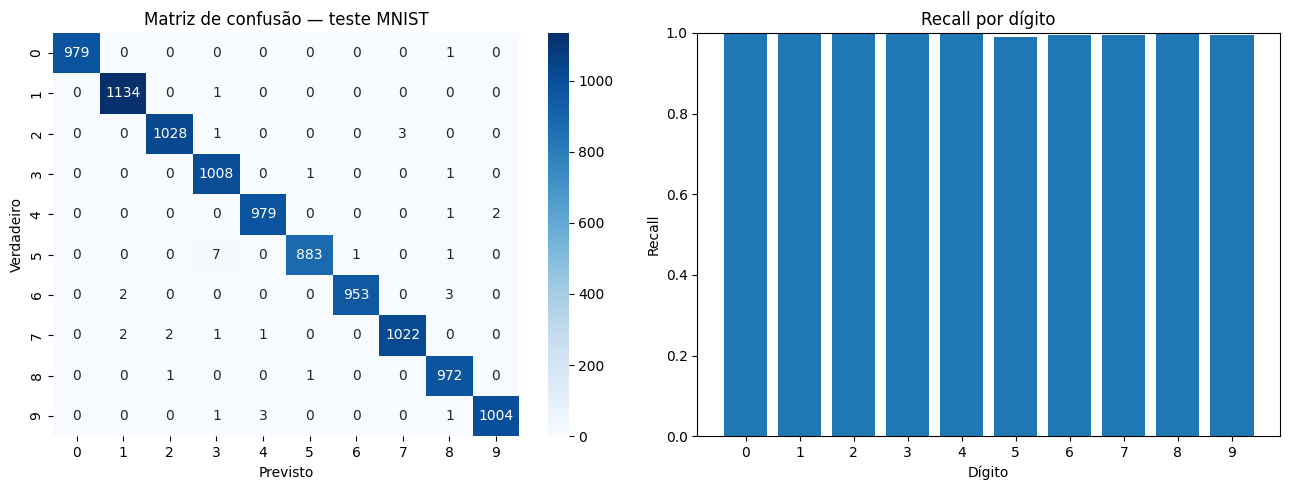

In [ ]:
p_teste = modelo_final.predict(x_teste[..., None], batch_size=256, verbose=0)
pred_teste = p_teste.argmax(1)
acc_teste = float((pred_teste == y_teste).mean())
cm = confusion_matrix(y_teste, pred_teste)

print('Acurácia no teste MNIST:', f'{acc_teste:.4%}')
display(pd.DataFrame(classification_report(
    y_teste, pred_teste, output_dict=True, zero_division=0
)).T.round(4))

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set(xlabel='Previsto', ylabel='Verdadeiro', title='Matriz de confusão — teste MNIST')
recall = np.diag(cm) / cm.sum(1)
axs[1].bar(range(10), recall)
axs[1].set(xticks=range(10), ylim=(0, 1), xlabel='Dígito', ylabel='Recall', title='Recall por dígito')
plt.tight_layout()
plt.savefig(PASTA / 'matriz_confusao_mnist.png', dpi=150)
plt.show()

salvar_json(PASTA / 'resultado_teste_mnist.json', {
    'acuracia_mnist': acc_teste,
    'n_teste': len(y_teste),
    'modelo_sha256': sha256(MODELO_FINAL)
})

## 14 — Funções de confiança com TTA

Para cada recorte, o modelo recebe pequenas rotações e translações. Uma previsão é aceita somente quando apresenta:

1. probabilidade mínima;
2. margem entre a primeira e a segunda classe;
3. concordância entre as transformações;
4. qualidade mínima de segmentação.

As funções desta etapa também são necessárias quando um modelo salvo é carregado em uma nova sessão.

In [ ]:
def criar_variantes_tta(recorte):
    variantes = [recorte]
    centro = (13.5, 13.5)
    for angulo in (-6, -3, 3, 6):
        m = cv2.getRotationMatrix2D(centro, angulo, 1.0)
        variantes.append(cv2.warpAffine(recorte, m, (28, 28), flags=cv2.INTER_LINEAR, borderValue=0))
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        m = np.float32([[1, 0, dx], [0, 1, dy]])
        variantes.append(cv2.warpAffine(recorte, m, (28, 28), flags=cv2.INTER_LINEAR, borderValue=0))
    return np.asarray(variantes, dtype=np.float32)[..., None]

def prever_com_tta(modelo, recortes):
    resultados = []
    for recorte in recortes:
        probs_variantes = modelo.predict(criar_variantes_tta(recorte), verbose=0)
        media = probs_variantes.mean(axis=0)
        ordem = np.argsort(media)[::-1]
        pred = int(ordem[0])
        resultados.append({
            'probabilidades': media,
            'digito': pred,
            'probabilidade': float(media[ordem[0]]),
            'margem': float(media[ordem[0]] - media[ordem[1]]),
            'acordo_tta': float((probs_variantes.argmax(1) == pred).mean())
        })
    return resultados

### 14.1 — Calibrar os critérios de rejeição

Se houver dados reais de calibração, os três primeiros limites são escolhidos neles. Caso contrário, são usados valores conservadores — nunca o antigo limiar de `0.10`.

In [ ]:
LIMIARES = {
    'probabilidade': .80,
    'margem': .25,
    'acordo_tta': .75,
    'qualidade_segmentacao': .35,
    'origem': 'valores_conservadores_sem_calibracao_real'
}

if (
    'x_real_cal' in globals()
    and 'y_real_cal' in globals()
    and len(x_real_cal) >= 30
    and len(np.unique(y_real_cal)) >= 5
):
    previsoes_cal = prever_com_tta(modelo_final, x_real_cal)
    tabela_cal = pd.DataFrame([{k: r[k] for k in ('digito', 'probabilidade', 'margem', 'acordo_tta')} for r in previsoes_cal])
    correto = tabela_cal.digito.to_numpy() == y_real_cal
    candidatos = []
    for prob in (.60, .70, .80, .85, .90, .95):
        for margem in (.10, .20, .30, .40, .50):
            for acordo in (.60, .75, .90, 1.00):
                aceito = (
                    (tabela_cal.probabilidade.to_numpy() >= prob) &
                    (tabela_cal.margem.to_numpy() >= margem) &
                    (tabela_cal.acordo_tta.to_numpy() >= acordo)
                )
                if aceito.any():
                    candidatos.append({
                        'probabilidade': prob, 'margem': margem, 'acordo_tta': acordo,
                        'acuracia_aceitos': float(correto[aceito].mean()),
                        'cobertura': float(aceito.mean()), 'n_aceitos': int(aceito.sum())
                    })
    tabela_limites = pd.DataFrame(candidatos)
    if len(tabela_limites):
        elegiveis = tabela_limites[(tabela_limites.acuracia_aceitos >= .95) & (tabela_limites.cobertura >= .50)]
        if len(elegiveis):
            escolhido = elegiveis.sort_values(['cobertura', 'acuracia_aceitos'], ascending=False).iloc[0]
        else:
            escolhido = tabela_limites.assign(
                utilidade=lambda d: d.acuracia_aceitos * d.cobertura
            ).sort_values(['utilidade', 'acuracia_aceitos'], ascending=False).iloc[0]
        LIMIARES.update({
            'probabilidade': float(escolhido.probabilidade),
            'margem': float(escolhido.margem),
            'acordo_tta': float(escolhido.acordo_tta),
            'origem': 'calibracao_real'
        })
        tabela_limites.to_csv(PASTA / 'grade_calibracao_confianca.csv', index=False)
    else:
        print('A calibração real não encontrou combinação utilizável; mantendo valores conservadores.')

else:
    print(
        'Calibração real não executada: faltam pelo menos 30 recortes '
        'reais rotulados, distribuídos em 5 ou mais dígitos. '
        'Mantendo limites conservadores.'
    )

salvar_json(PASTA / 'criterios_rejeicao.json', LIMIARES)
print('Critérios de rejeição:', LIMIARES)

Calibração real não executada: faltam pelo menos 30 recortes reais rotulados, distribuídos em 5 ou mais dígitos. Mantendo limites conservadores.
Critérios de rejeição: {'probabilidade': 0.8, 'margem': 0.25, 'acordo_tta': 0.75, 'qualidade_segmentacao': 0.35, 'origem': 'valores_conservadores_sem_calibracao_real'}


## 15 — Orientação manual e análise completa

A orientação automática foi temporariamente desativada porque uma previsão confiante não garante que o recorte ou a rotação estejam corretos.

Use uma das opções: `0`, `90`, `-90` ou `180`. Se as fotografias tiverem orientações diferentes, envie uma por vez ou separe-as em grupos com a mesma orientação.

A orientação automática poderá voltar quando houver fotografias reais rotuladas suficientes para validá-la.

In [ ]:
def esta_aceito(
    previsao,
    qualidade
):
    return bool(
        previsao['probabilidade']
        >= LIMIARES['probabilidade']

        and previsao['margem']
        >= LIMIARES['margem']

        and previsao['acordo_tta']
        >= LIMIARES['acordo_tta']

        and qualidade
        >= LIMIARES['qualidade_segmentacao']
    )


def analisar_foto(
    imagem,
    modo='um_digito',
    rotacao=0,
    roi=None,
    quantidade_esperada=None
):
    if str(rotacao).upper() == 'AUTO':
        raise ValueError(
            'A orientação automática foi desativada. '
            'Use 0, 90, -90 ou 180.'
        )

    rotacao = int(rotacao)

    extracao = extrair_digitos(
        imagem,
        modo=modo,
        rotacao=rotacao,
        roi=roi
    )

    previsoes = prever_com_tta(
        modelo_final,
        extracao['recortes']
    )

    aceitos = [
        esta_aceito(
            previsao,
            qualidade
        )
        for previsao, qualidade in zip(
            previsoes,
            extracao['qualidades']
        )
    ]

    quantidade_correta = (
        quantidade_esperada is None
        or len(previsoes) == quantidade_esperada
    )

    if not quantidade_correta:
        aceitos = [
            False
            for _ in aceitos
        ]

    return {
        'extracao': extracao,
        'previsoes': previsoes,
        'aceitos': aceitos,
        'rotacao': rotacao,
        'quantidade_correta': quantidade_correta
    }

## 16 — Carregar o modelo sem treinar novamente

Em uma sessão nova, execute nesta ordem:

1. ambiente e configuração (passos 1 e 2);
2. funções de segmentação (passo 7);
3. funções TTA (passo 14, sem executar a calibração 14.1);
4. funções de orientação (passo 15);
5. esta célula e, depois, a demonstração do passo 17.

Cole uma pasta de execução em `PASTA_MODELO` ou deixe vazio para localizar a execução concluída mais recente.

In [ ]:
import hashlib

def sha256(caminho):
    hash_arquivo = hashlib.sha256()

    with open(caminho, 'rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(1024 * 1024), b''):
            hash_arquivo.update(bloco)

    return hash_arquivo.hexdigest()

In [ ]:
PASTA_MODELO = ''
raiz_execucoes = Path('/content/drive/MyDrive/DigitCheck_V3/execucoes')

if PASTA_MODELO:
    pasta_modelo = Path(PASTA_MODELO)
elif 'PASTA' in globals() and (Path(PASTA) / 'melhor_modelo.keras').exists():
    pasta_modelo = Path(PASTA)
else:
    concluidas = sorted(
        p.parent for p in raiz_execucoes.glob('*/melhor_modelo.keras')
        if (p.parent / 'selecao.json').exists()
    )
    if not concluidas:
        raise FileNotFoundError('Nenhuma execução concluída encontrada. Informe PASTA_MODELO.')
    pasta_modelo = concluidas[-1]

PASTA = pasta_modelo
MODELO_FINAL = PASTA / 'melhor_modelo.keras'
modelo_final = tf.keras.models.load_model(MODELO_FINAL, compile=False)
arquivo_criterios = PASTA / 'criterios_rejeicao.json'
if arquivo_criterios.exists():
    LIMIARES = json.loads(arquivo_criterios.read_text(encoding='utf-8'))
else:
    LIMIARES = {
        'probabilidade': .80, 'margem': .25, 'acordo_tta': .75,
        'qualidade_segmentacao': .35, 'origem': 'fallback_conservador'
    }

print('✅ Modelo:', MODELO_FINAL)
print('SHA-256:', sha256(MODELO_FINAL))
print('Critérios:', LIMIARES)

✅ Modelo: /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/melhor_modelo.keras
SHA-256: 346945df1a808276b582afa21453775aa51a3eaad1de9244cb6aa94d7a608fa7
Critérios: {'probabilidade': 0.8, 'margem': 0.25, 'acordo_tta': 0.75, 'qualidade_segmentacao': 0.35, 'origem': 'valores_conservadores_sem_calibracao_real'}


## 17 — Demonstração com fotografias

Escolha primeiro se as imagens contêm um único dígito ou uma sequência.

Não envie fotos com orientações diferentes na mesma execução. Para descobrir a rotação correta, teste `0`, `90`, `-90` ou `180`.

Se a foto tiver outros desenhos, círculos ou anotações, recorte-a antes do envio ou informe uma região em `ROI_MANUAL`.

Saving WhatsApp Image 2026-09-18 at 12.24.55 (1).jpeg to WhatsApp Image 2026-09-18 at 12.24.55 (1) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.55 (2).jpeg to WhatsApp Image 2026-09-18 at 12.24.55 (2) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.55 (3).jpeg to WhatsApp Image 2026-09-18 at 12.24.55 (3) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56.jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (5).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (1).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (1) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (2).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (2) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (3).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (3) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (4).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (4) (1).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.57.jpeg to WhatsApp Image 2026-09-18 at 12.24.57 (4).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.57

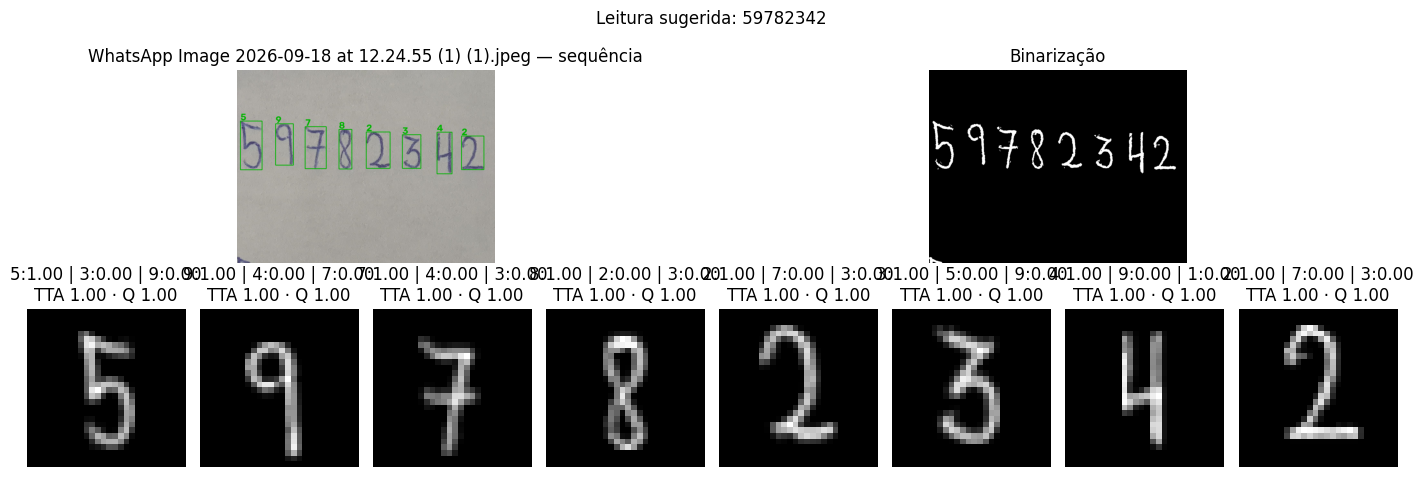

Previsão bruta: 59782342
Resultado: 59782342


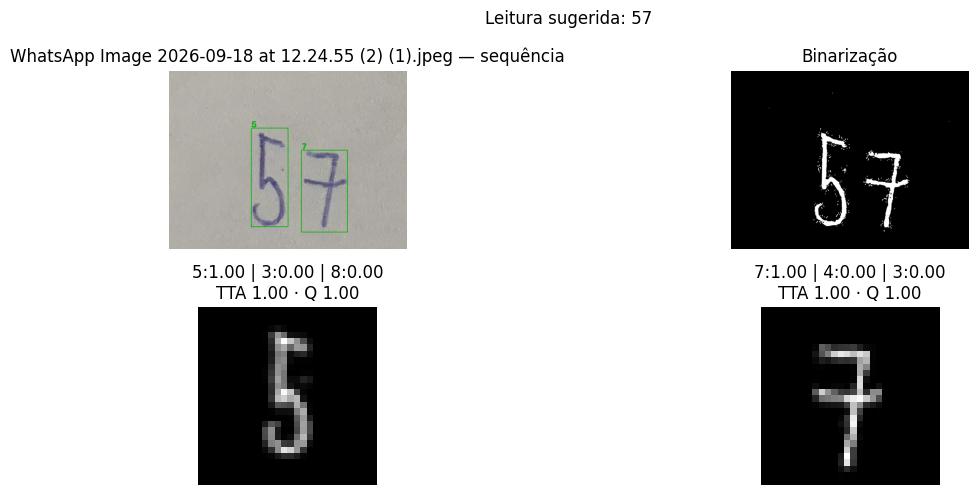

Previsão bruta: 57
Resultado: 57


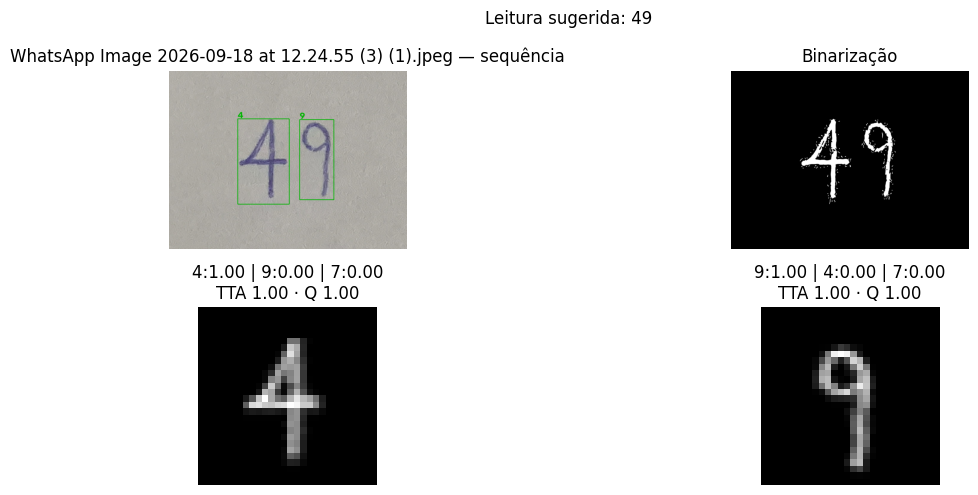

Previsão bruta: 49
Resultado: 49


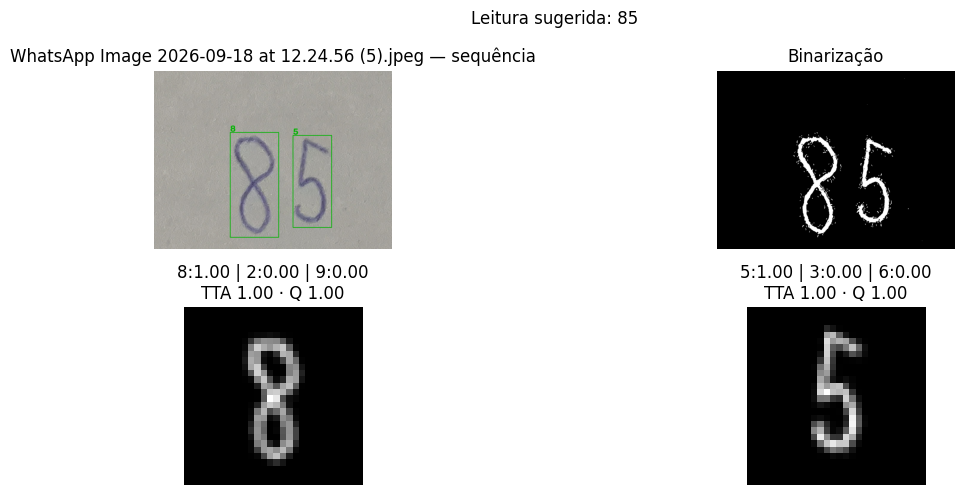

Previsão bruta: 85
Resultado: 85


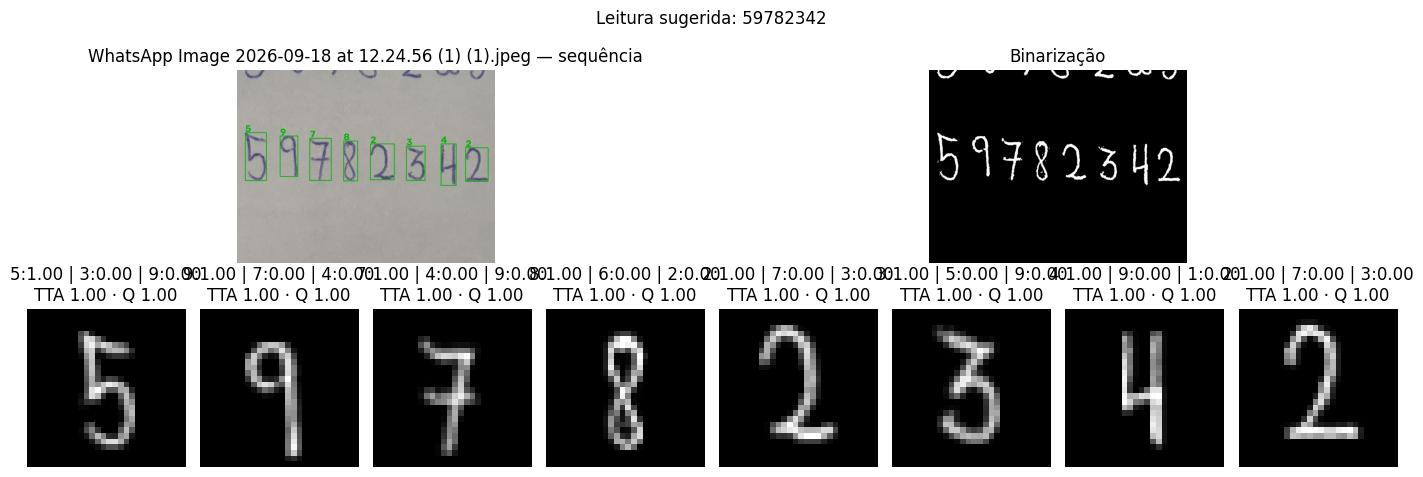

Previsão bruta: 59782342
Resultado: 59782342


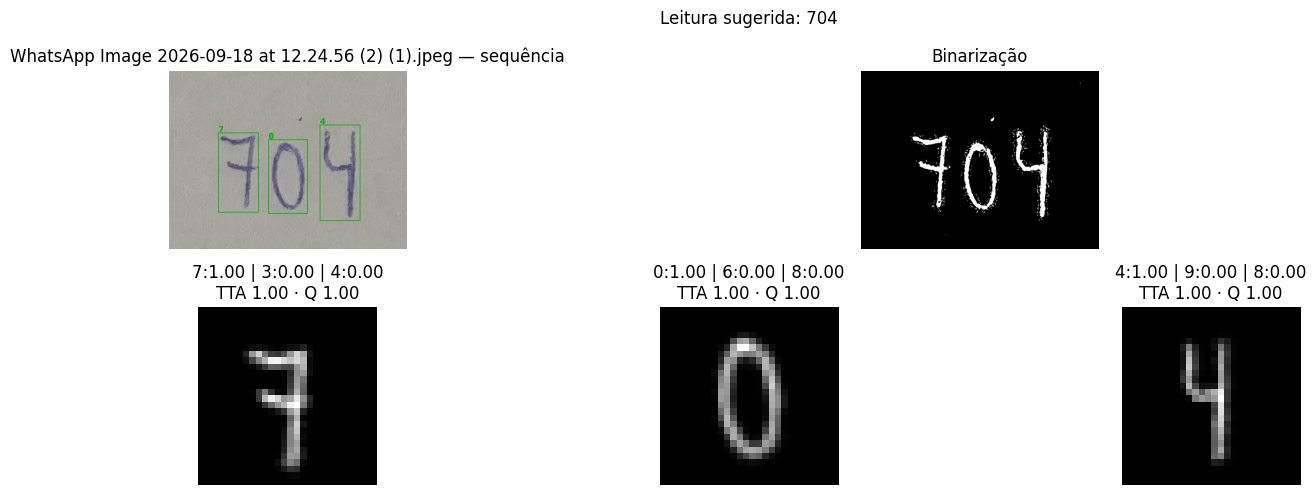

Previsão bruta: 704
Resultado: 704


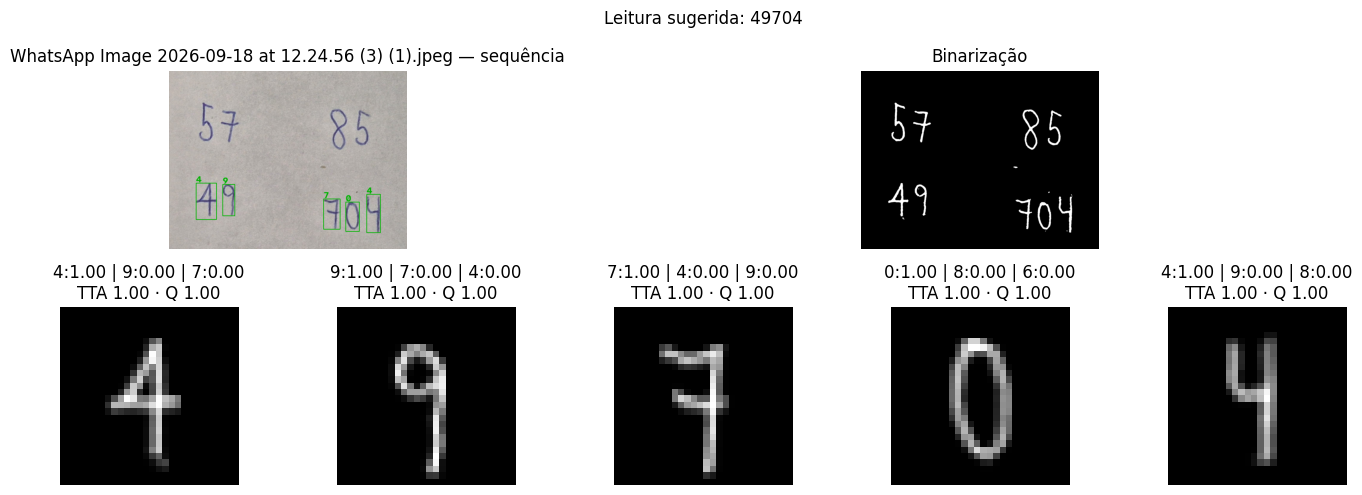

Previsão bruta: 49704
Resultado: 49704


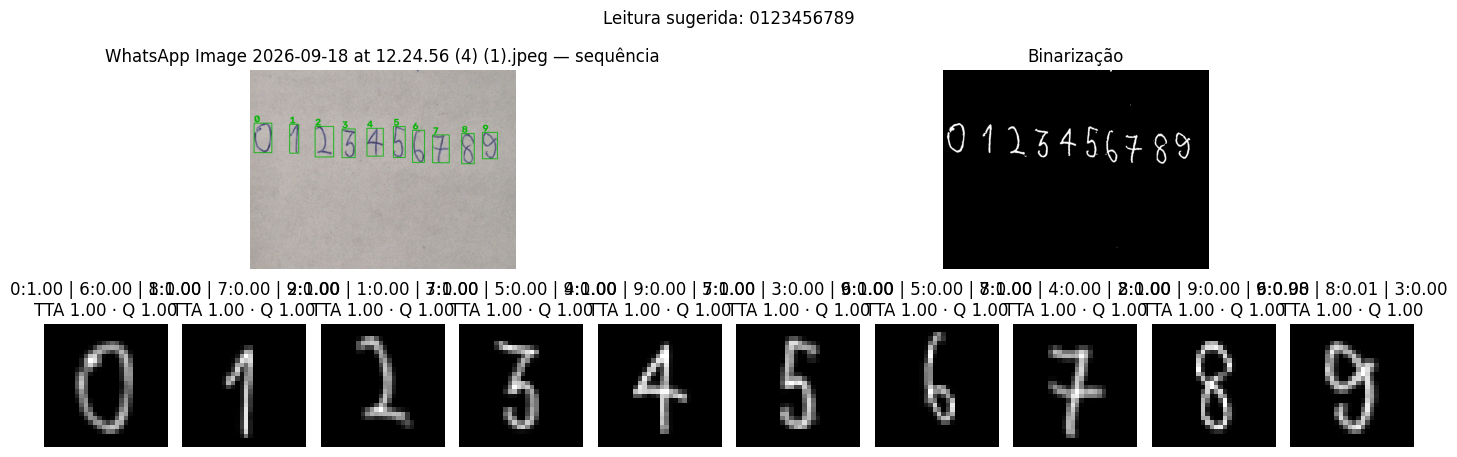

Previsão bruta: 0123456789
Resultado: 0123456789


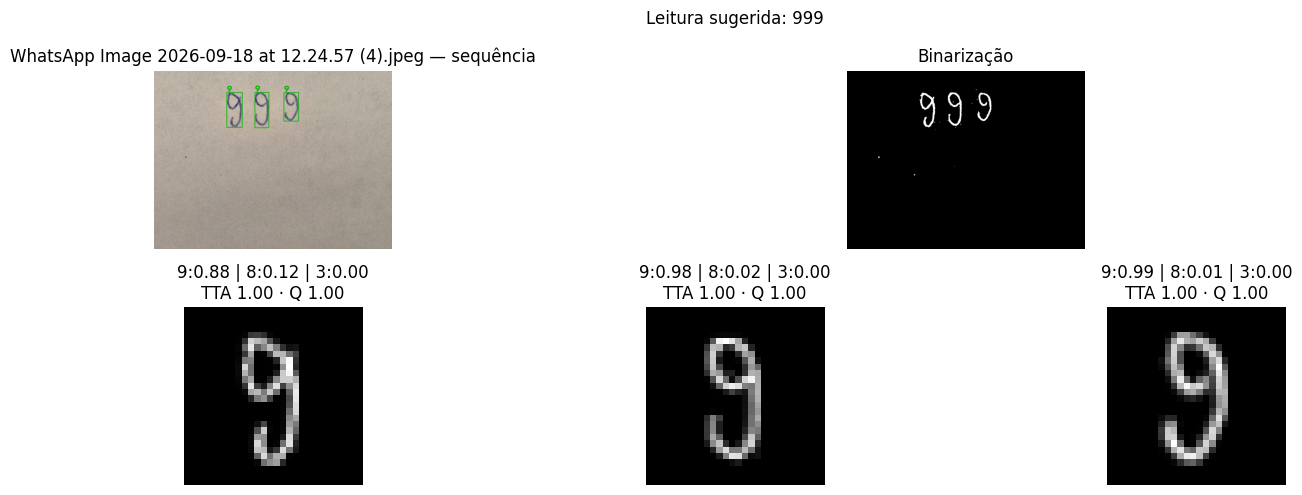

Previsão bruta: 999
Resultado: 999


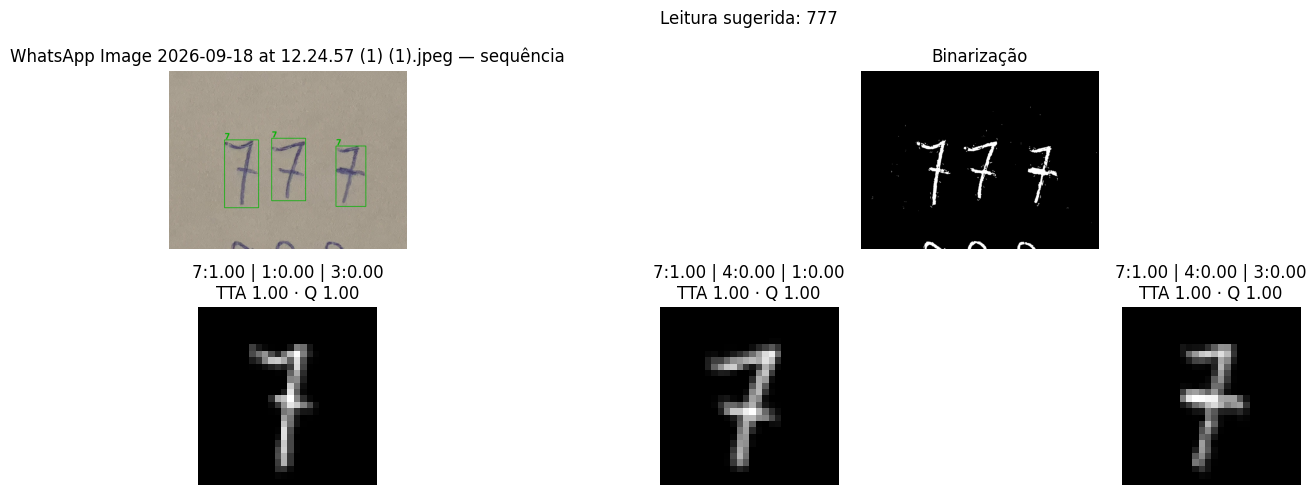

Previsão bruta: 777
Resultado: 777


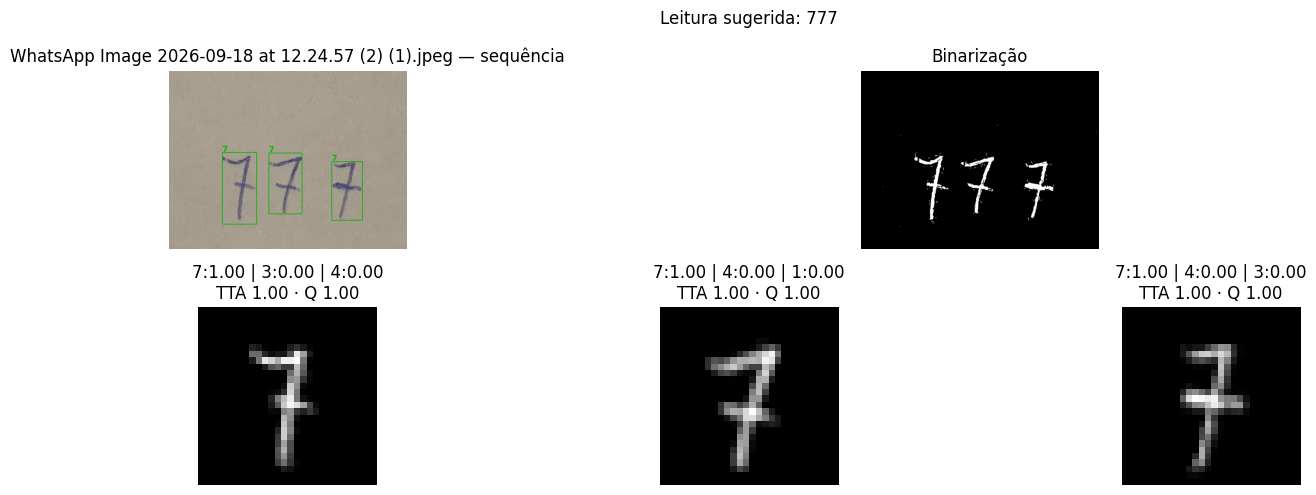

Previsão bruta: 777
Resultado: 777


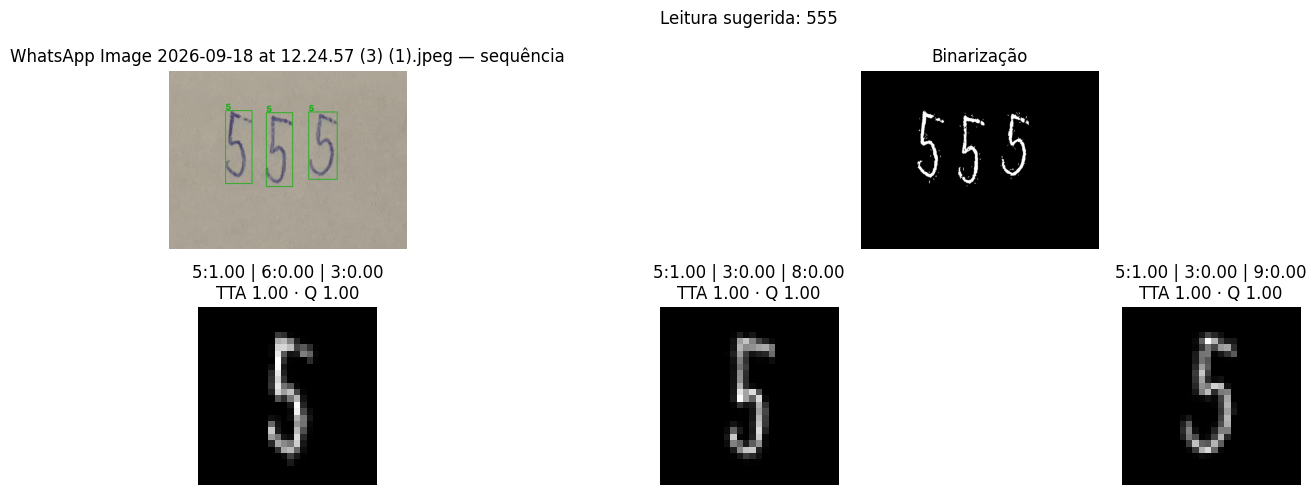

Previsão bruta: 555
Resultado: 555
Resultados salvos em: /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/leituras/20260922_225943_854329


In [ ]:
MODO_LEITURA = 'sequencia'
ROTACAO_FOTO = 0
ROI_MANUAL = None
QUANTIDADE_ESPERADA = None

enviados = files.upload()

if not enviados:
    raise ValueError(
        'Nenhuma imagem enviada.'
    )

PASTA_FOTOS = (
    PASTA
    / 'leituras'
    / datetime.now().strftime(
        '%Y%m%d_%H%M%S_%f'
    )
)

PASTA_FOTOS.mkdir(
    parents=True,
    exist_ok=True
)

leituras = []

for numero, (nome, conteudo) in enumerate(
    enviados.items()
):
    try:
        analise = analisar_foto(
            Image.open(
                io.BytesIO(conteudo)
            ),
            modo='sequencia',
            rotacao=ROTACAO_FOTO,
            roi=ROI_MANUAL,
            quantidade_esperada=None
        )

    except Exception as erro:
        print(
            '❌',
            nome,
            ':',
            erro
        )
        continue

    extracao = analise['extracao']
    previsoes = analise['previsoes']
    aceitos = analise['aceitos']

    digitos = [
        previsao['digito']
        for previsao in previsoes
    ]

    leitura = ''.join(
        str(digito)
        if aceito
        else '?'
        for digito, aceito in zip(
            digitos,
            aceitos
        )
    )

    marcado = extracao[
        'original'
    ].copy()

    for (
        caixa,
        digito,
        aceito
    ) in zip(
        extracao['caixas'],
        digitos,
        aceitos
    ):
        x, y, w, h = caixa

        cor = (
            (0, 180, 0)
            if aceito
            else (255, 0, 0)
        )

        cv2.rectangle(
            marcado,
            (x, y),
            (x + w, y + h),
            cor,
            max(
                1,
                marcado.shape[0] // 250
            )
        )

        cv2.putText(
            marcado,
            str(digito),
            (x, max(15, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            max(
                0.5,
                marcado.shape[0] / 600
            ),
            cor,
            2
        )

    prefixo = (
        f'{numero:02d}_'
        + re.sub(
            r'[^a-zA-Z0-9_-]+',
            '_',
            Path(nome).stem
        )[:50]
    )

    Image.fromarray(
        extracao['original']
    ).save(
        PASTA_FOTOS
        / f'{prefixo}_orientada.jpg'
    )

    Image.fromarray(
        extracao['binario']
    ).save(
        PASTA_FOTOS
        / f'{prefixo}_binario.png'
    )

    Image.fromarray(
        marcado
    ).save(
        PASTA_FOTOS
        / f'{prefixo}_marcado.jpg'
    )

    leituras.append({
        'arquivo': nome,
        'leitura_sugerida': leitura,
        'previsao_bruta': ''.join(
            map(str, digitos)
        ),
        'rotacao': ROTACAO_FOTO,
        'probabilidades': [
            previsao['probabilidade']
            for previsao in previsoes
        ],
        'margens': [
            previsao['margem']
            for previsao in previsoes
        ],
        'acordos_tta': [
            previsao['acordo_tta']
            for previsao in previsoes
        ],
        'qualidades_segmentacao':
            extracao['qualidades'],
        'aceitos': aceitos,
        'n_digitos': len(digitos)
    })

    colunas = max(
        2,
        len(extracao['recortes'])
    )

    fig = plt.figure(
        figsize=(14, 5)
    )

    grade = fig.add_gridspec(
        2,
        colunas
    )

    divisao = max(
        1,
        colunas // 2
    )

    ax1 = fig.add_subplot(
        grade[0, :divisao]
    )

    ax1.imshow(marcado)
    ax1.axis('off')
    ax1.set_title(
        f'{nome} — sequência'
    )

    ax2 = fig.add_subplot(
        grade[0, divisao:]
    )

    ax2.imshow(
        extracao['binario'],
        cmap='gray'
    )

    ax2.axis('off')
    ax2.set_title('Binarização')

    for indice, (
        recorte,
        previsao,
        qualidade,
        aceito
    ) in enumerate(zip(
        extracao['recortes'],
        previsoes,
        extracao['qualidades'],
        aceitos
    )):
        ax = fig.add_subplot(
            grade[1, indice]
        )

        ax.imshow(
            recorte,
            cmap='gray'
        )

        ax.axis('off')

        top3 = np.argsort(
            previsao['probabilidades']
        )[-3:][::-1]

        resumo = ' | '.join(
            f'{digito}:'
            f'{previsao["probabilidades"][digito]:.2f}'
            for digito in top3
        )

        aviso = (
            ''
            if aceito
            else ' ⚠'
        )

        ax.set_title(
            f'{resumo}\n'
            f'TTA {previsao["acordo_tta"]:.2f}'
            f' · Q {qualidade:.2f}'
            f'{aviso}'
        )

    plt.suptitle(
        f'Leitura sugerida: {leitura}'
    )

    plt.tight_layout()
    plt.show()

    print(
        'Previsão bruta:',
        ''.join(
            map(str, digitos)
        )
    )

    print(
        'Resultado:',
        leitura
    )

pd.DataFrame(
    leituras
).to_csv(
    PASTA_FOTOS / 'leituras.csv',
    index=False
)

print(
    'Resultados salvos em:',
    PASTA_FOTOS
)

## 18 — Avaliação real em três níveis

Esta célula usa somente `dados_reais/teste` e relata:

- **taxa de segmentação:** proporção de fotos em que um candidato foi encontrado;
- **acurácia condicional:** classificação correta entre fotos segmentadas;
- **acurácia bruta fim a fim:** foto correta desde a entrada até a classe, contando falhas de segmentação como erro;
- **cobertura operacional:** proporção aceita sem revisão;
- **acurácia entre aceitos:** precisão das respostas liberadas automaticamente.

Essas métricas impedem que uma CNN excelente esconda uma segmentação ruim.

In [1]:
print("caminhos_rotulados existe?", 'caminhos_rotulados' in globals())
print("PASTA_DADOS_REAIS existe?", 'PASTA_DADOS_REAIS' in globals())

if 'PASTA_DADOS_REAIS' in globals():
    print("PASTA_DADOS_REAIS =", PASTA_DADOS_REAIS)
    print("Existe?", PASTA_DADOS_REAIS.exists())

caminhos_rotulados existe? False
PASTA_DADOS_REAIS existe? False


In [ ]:
ROTACAO_AVALIACAO_REAL = 'AUTO'
registros_teste_real = []

for caminho, rotulo in caminhos_rotulados('teste'):
    registro = {'arquivo': str(caminho), 'rotulo': rotulo}
    try:
        analise = analisar_foto(
            Image.open(caminho), modo='um_digito',
            rotacao=ROTACAO_AVALIACAO_REAL, quantidade_esperada=1
        )
        previsao = analise['previsoes'][0]
        aceito = bool(analise['aceitos'][0])
        registro.update({
            'segmentado': True,
            'predito': previsao['digito'],
            'correto': previsao['digito'] == rotulo,
            'aceito': aceito,
            'probabilidade': previsao['probabilidade'],
            'margem': previsao['margem'],
            'acordo_tta': previsao['acordo_tta'],
            'qualidade': analise['extracao']['qualidades'][0],
            'rotacao': analise['rotacao'],
            'orientacao_ambigua': analise['orientacao_ambigua'],
            'erro': ''
        })
    except Exception as erro:
        registro.update({
            'segmentado': False, 'predito': np.nan, 'correto': False,
            'aceito': False, 'probabilidade': 0.0, 'margem': 0.0,
            'acordo_tta': 0.0, 'qualidade': 0.0, 'rotacao': np.nan,
            'orientacao_ambigua': False, 'erro': str(erro)
        })
    registros_teste_real.append(registro)

resultado_real_df = pd.DataFrame(registros_teste_real)
if resultado_real_df.empty:
    print('Nenhuma fotografia encontrada em:', PASTA_DADOS_REAIS / 'teste')
else:
    segmentadas = resultado_real_df.segmentado
    aceitas = resultado_real_df.aceito
    metricas_reais = {
        'n_fotos': int(len(resultado_real_df)),
        'taxa_segmentacao': float(segmentadas.mean()),
        'acuracia_classificacao_condicional': float(resultado_real_df.loc[segmentadas, 'correto'].mean()) if segmentadas.any() else None,
        'acuracia_bruta_fim_a_fim': float(resultado_real_df.correto.mean()),
        'cobertura_operacional': float(aceitas.mean()),
        'acuracia_entre_aceitos': float(resultado_real_df.loc[aceitas, 'correto'].mean()) if aceitas.any() else None
    }
    display(pd.DataFrame([metricas_reais]).style.format({
        'taxa_segmentacao': '{:.2%}',
        'acuracia_classificacao_condicional': lambda v: '—' if pd.isna(v) else f'{v:.2%}',
        'acuracia_bruta_fim_a_fim': '{:.2%}',
        'cobertura_operacional': '{:.2%}',
        'acuracia_entre_aceitos': lambda v: '—' if pd.isna(v) else f'{v:.2%}'
    }))
    display(resultado_real_df)
    resultado_real_df.to_csv(PASTA / 'resultado_detalhado_teste_real.csv', index=False)
    salvar_json(PASTA / 'metricas_teste_real.json', metricas_reais)

    if segmentadas.any():
        y_real_ok = resultado_real_df.loc[segmentadas, 'rotulo'].astype(int)
        pred_real_ok = resultado_real_df.loc[segmentadas, 'predito'].astype(int)
        cm_real = confusion_matrix(y_real_ok, pred_real_ok, labels=range(10))
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_real, annot=True, fmt='d', cmap='Purples')
        plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')
        plt.title('Matriz de confusão — fotografias segmentadas')
        plt.tight_layout()
        plt.savefig(PASTA / 'matriz_confusao_fotos_reais.png', dpi=150)
        plt.show()

NameError: name 'caminhos_rotulados' is not defined

## 19 — Exportar para ONNX

As camadas aleatórias são usadas somente no treinamento. O grafo de inferência abaixo reutiliza exatamente os pesos treinados, pula essas camadas e compara as saídas Keras antes da conversão.

In [ ]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "protobuf==6.31.1",
    "onnx",
    "tf2onnx",
    "onnxruntime"
])

print("✅ Instalação concluída.")

✅ Instalação concluída.


In [ ]:
import onnx
import onnxruntime
import tf2onnx
import google.protobuf

print("✅ onnx:", onnx.__version__)
print("✅ onnxruntime:", onnxruntime.__version__)
print("✅ tf2onnx:", tf2onnx.__version__)
print("✅ protobuf:", google.protobuf.__version__)

/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

✅ onnx: 1.23.0
✅ onnxruntime: 1.30.0
✅ tf2onnx: 1.17.0
✅ protobuf: 6.31.1


In [ ]:
import google.protobuf
import onnx
import onnxruntime
import tf2onnx

print("protobuf:", google.protobuf.__version__)
print("onnx:", onnx.__version__)
print("onnxruntime:", onnxruntime.__version__)
print("tf2onnx:", tf2onnx.__version__)

VersionError: Detected incompatible Protobuf Gencode/Runtime versions when loading onnx/onnx-ml.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

In [ ]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "protobuf==6.31.1",
    "onnx",
    "tf2onnx",
    "onnxruntime"
])

print("✅ Dependências corrigidas.")
print("⚠️ Agora reinicie a sessão do Colab.")

KeyboardInterrupt: 

In [ ]:
print('Entrada:', modelo_final.input_shape)
print('Saída:', modelo_final.output_shape)

Entrada: (None, 28, 28, 1)
Saída: (None, 10)


In [ ]:
from pathlib import Path
from google.colab import files

labels = [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
]

caminho_labels = PASTA / "labels.txt"

caminho_labels.write_text(
    "\n".join(labels),
    encoding="utf-8"
)

print("✅ labels.txt criado em:")
print(caminho_labels)

print()
print("Conteúdo:")
print(
    caminho_labels.read_text(
        encoding="utf-8"
    )
)

files.download(
    str(caminho_labels)
)

✅ labels.txt criado em:
/content/drive/MyDrive/DigitCheck_V3/execucoes/20260922_223507_226020/labels.txt

Conteúdo:
0
1
2
3
4
5
6
7
8
9


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# ETAPA 19 — EXPORTAR ONNX E VALIDAR COM OS MESMOS RECORTES
# DA ETAPA 17
# ============================================================

import sys
import subprocess
from pathlib import Path

import numpy as np
import tensorflow as tf

try:
    import tf2onnx
except ImportError:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'tf2onnx'
    ])
    import tf2onnx

try:
    import onnxruntime as ort
except ImportError:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'onnxruntime'
    ])
    import onnxruntime as ort


# ------------------------------------------------------------
# 1. Criar modelo de inferência sem augmentation
# ------------------------------------------------------------

tipos_aleatorios = (
    tf.keras.layers.RandomTranslation,
    tf.keras.layers.RandomRotation,
    tf.keras.layers.RandomZoom
)

entrada = tf.keras.Input(
    shape=(28, 28, 1),
    dtype=tf.float32,
    name='imagem_0_255'
)

x = entrada

for camada in modelo_final.layers:

    if isinstance(
        camada,
        tipos_aleatorios
    ):
        print(
            'Ignorando camada de augmentation:',
            camada.name
        )
        continue

    if isinstance(
        camada,
        (
            tf.keras.layers.Dropout,
            tf.keras.layers.BatchNormalization
        )
    ):
        x = camada(
            x,
            training=False
        )
    else:
        x = camada(x)


modelo_inferencia = tf.keras.Model(
    entrada,
    x,
    name='DigitCheck_Inferencia'
)

print()
print('✅ Modelo de inferência criado')
print('Entrada:', modelo_inferencia.input_shape)
print('Saída:', modelo_inferencia.output_shape)


# ------------------------------------------------------------
# 2. Validar Keras original × modelo de inferência
#
# Usa recortes reais da última execução da Etapa 17
# ------------------------------------------------------------

if 'extracao' not in globals():
    raise RuntimeError(
        'Não encontrei os recortes da Etapa 17. '
        'Rode primeiro a Etapa 17 com uma foto de sequência.'
    )

recortes_reais = extracao.get(
    'recortes',
    []
)

if not recortes_reais:
    raise RuntimeError(
        'A Etapa 17 não produziu nenhum recorte.'
    )


amostras = []

for recorte in recortes_reais:

    arr = np.asarray(
        recorte,
        dtype=np.float32
    )

    if arr.ndim == 2:
        arr = arr[..., None]

    if arr.shape != (28, 28, 1):
        raise RuntimeError(
            f'Recorte com formato inesperado: {arr.shape}'
        )

    amostras.append(
        arr
    )


amostra_verificacao = np.stack(
    amostras,
    axis=0
).astype(np.float32)


saida_original = modelo_final(
    amostra_verificacao,
    training=False
).numpy()


saida_inferencia = modelo_inferencia(
    amostra_verificacao,
    training=False
).numpy()


diferenca_keras = float(
    np.max(
        np.abs(
            saida_original
            -
            saida_inferencia
        )
    )
)


classes_original = np.argmax(
    saida_original,
    axis=1
)

classes_inferencia = np.argmax(
    saida_inferencia,
    axis=1
)


print()
print('=== KERAS ORIGINAL × KERAS INFERÊNCIA ===')

print(
    'Classes original:',
    classes_original.tolist()
)

print(
    'Classes inferência:',
    classes_inferencia.tolist()
)

print(
    'Maior diferença:',
    diferenca_keras
)


if not np.array_equal(
    classes_original,
    classes_inferencia
):
    raise RuntimeError(
        '❌ O modelo de inferência mudou as classes.'
    )


if diferenca_keras > 1e-5:
    raise RuntimeError(
        '❌ O grafo de inferência não reproduziu '
        'o modelo original.'
    )


print('✅ Keras reproduzido corretamente')


# ------------------------------------------------------------
# 3. Exportar ONNX
# ------------------------------------------------------------

nome_onnx = (
    'modelo_digitcheck_sequencia_v2.onnx'
)

caminho_onnx = (
    PASTA
    /
    nome_onnx
)


spec = (
    tf.TensorSpec(
        shape=(
            None,
            28,
            28,
            1
        ),
        dtype=tf.float32,
        name='imagem_0_255'
    ),
)


tf2onnx.convert.from_keras(
    modelo_inferencia,
    input_signature=spec,
    opset=13,
    output_path=str(
        caminho_onnx
    )
)


print()
print(
    '✅ ONNX salvo em:',
    caminho_onnx
)


# ------------------------------------------------------------
# 4. Carregar ONNX de volta
# ------------------------------------------------------------

sessao = ort.InferenceSession(
    str(caminho_onnx),
    providers=[
        'CPUExecutionProvider'
    ]
)


nome_entrada = (
    sessao
    .get_inputs()[0]
    .name
)


saida_onnx = sessao.run(
    None,
    {
        nome_entrada:
            amostra_verificacao
    }
)[0]


classes_onnx = np.argmax(
    saida_onnx,
    axis=1
)


diferenca_onnx = float(
    np.max(
        np.abs(
            saida_inferencia
            -
            saida_onnx
        )
    )
)


print()
print('=== KERAS × ONNX ===')

print(
    'Classes Keras:',
    classes_inferencia.tolist()
)

print(
    'Classes ONNX:',
    classes_onnx.tolist()
)

print(
    'Maior diferença:',
    diferenca_onnx
)


if not np.array_equal(
    classes_inferencia,
    classes_onnx
):
    raise RuntimeError(
        '❌ ONNX não reproduziu as mesmas classes.'
    )


print(
    '✅ ONNX reproduziu corretamente '
    'os recortes reais da Etapa 17.'
)


# ------------------------------------------------------------
# 5. Baixar ONNX
# ------------------------------------------------------------

files.download(
    str(caminho_onnx)
)

Ignorando camada de augmentation: random_translation
Ignorando camada de augmentation: random_rotation
Ignorando camada de augmentation: random_zoom

✅ Modelo de inferência criado
Entrada: (None, 28, 28, 1)
Saída: (None, 10)

=== KERAS ORIGINAL × KERAS INFERÊNCIA ===
Classes original: [5, 5, 5]
Classes inferência: [5, 5, 5]
Maior diferença: 0.0
✅ Keras reproduzido corretamente

✅ ONNX salvo em: /content/drive/MyDrive/DigitCheck_V3/execucoes/20260921_113226_741814/modelo_digitcheck_sequencia_v2.onnx

=== KERAS × ONNX ===
Classes Keras: [5, 5, 5]
Classes ONNX: [5, 5, 5]
Maior diferença: 1.1920928955078125e-07
✅ ONNX reproduziu corretamente os recortes reais da Etapa 17.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ONNX carregado
Entrada: imagem_0_255


Saving WhatsApp Image 2026-09-18 at 12.24.55 (1).jpeg to WhatsApp Image 2026-09-18 at 12.24.55 (1) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.55 (2).jpeg to WhatsApp Image 2026-09-18 at 12.24.55 (2) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.55 (3).jpeg to WhatsApp Image 2026-09-18 at 12.24.55 (3) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56.jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (6).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (1).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (1) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (2).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (2) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (3).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (3) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.56 (4).jpeg to WhatsApp Image 2026-09-18 at 12.24.56 (4) (2).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.57.jpeg to WhatsApp Image 2026-09-18 at 12.24.57 (5).jpeg
Saving WhatsApp Image 2026-09-18 at 12.24.57

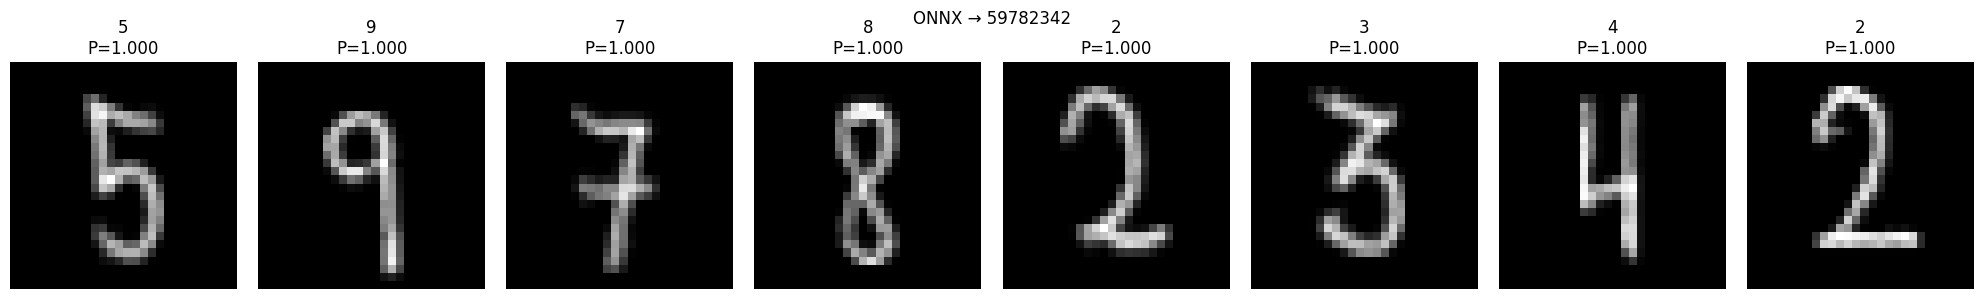


Arquivo: WhatsApp Image 2026-09-18 at 12.24.55 (2) (2).jpeg
Recortes encontrados: 2
Previsões ONNX: [5, 7]
Sequência ONNX: 57


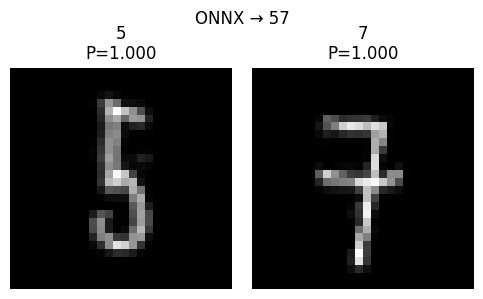


Arquivo: WhatsApp Image 2026-09-18 at 12.24.55 (3) (2).jpeg
Recortes encontrados: 2
Previsões ONNX: [4, 9]
Sequência ONNX: 49


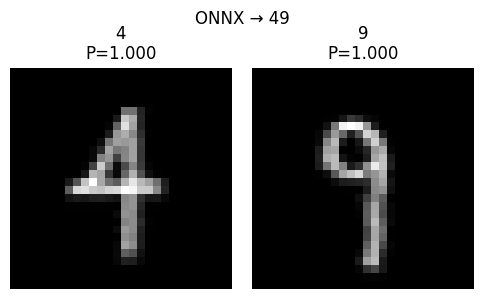


Arquivo: WhatsApp Image 2026-09-18 at 12.24.56 (6).jpeg
Recortes encontrados: 2
Previsões ONNX: [8, 5]
Sequência ONNX: 85


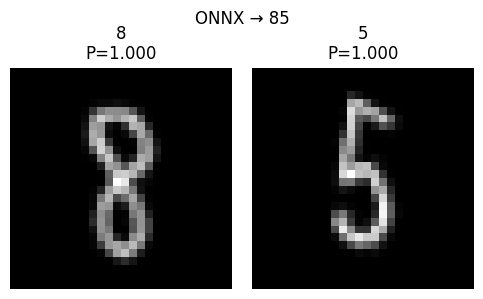


Arquivo: WhatsApp Image 2026-09-18 at 12.24.56 (1) (2).jpeg
Recortes encontrados: 8
Previsões ONNX: [5, 9, 7, 8, 2, 3, 4, 2]
Sequência ONNX: 59782342


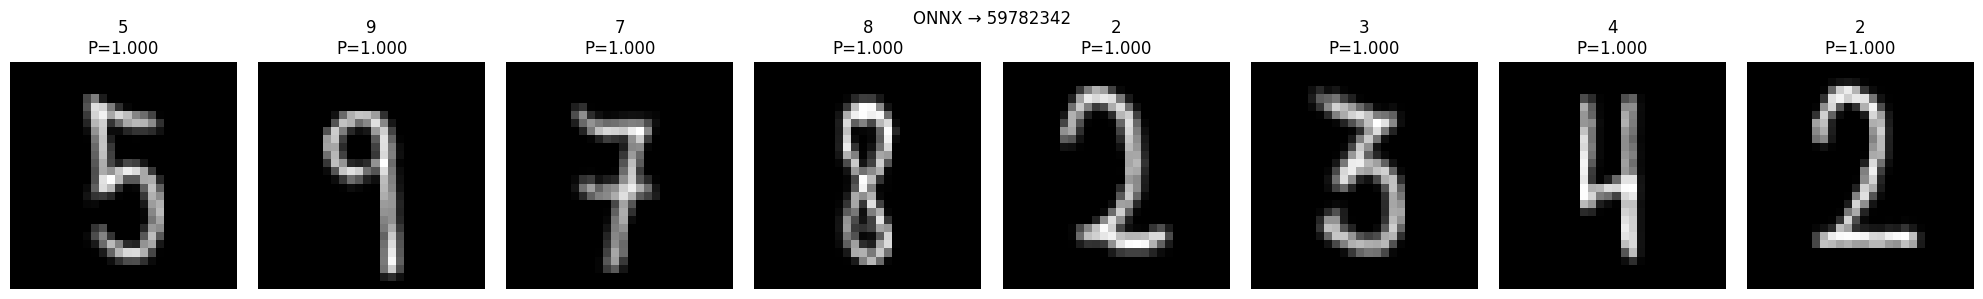


Arquivo: WhatsApp Image 2026-09-18 at 12.24.56 (2) (2).jpeg
Recortes encontrados: 3
Previsões ONNX: [7, 0, 4]
Sequência ONNX: 704


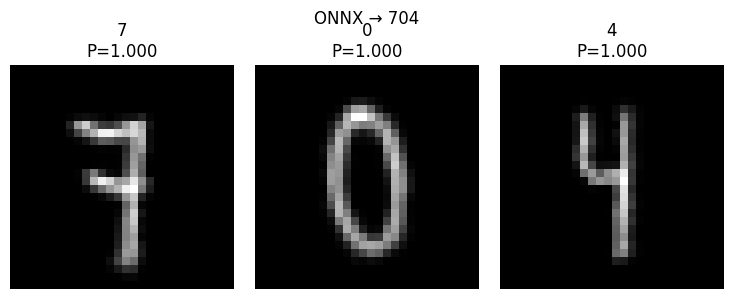


Arquivo: WhatsApp Image 2026-09-18 at 12.24.56 (3) (2).jpeg
Recortes encontrados: 5
Previsões ONNX: [4, 9, 7, 0, 4]
Sequência ONNX: 49704


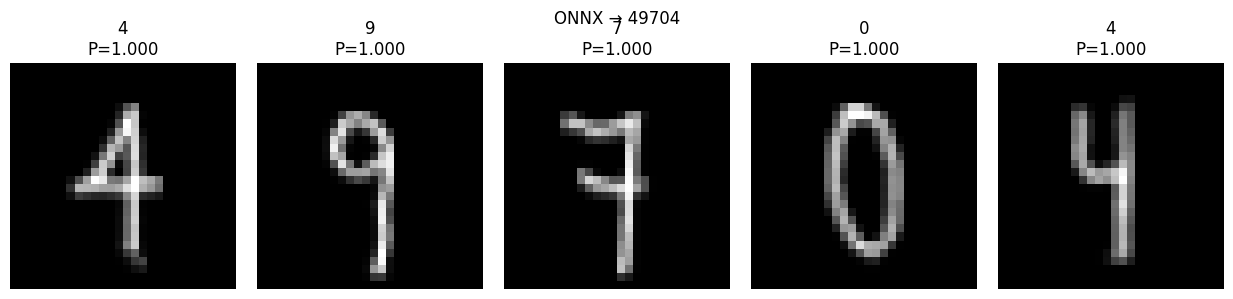


Arquivo: WhatsApp Image 2026-09-18 at 12.24.56 (4) (2).jpeg
Recortes encontrados: 10
Previsões ONNX: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Sequência ONNX: 0123456789


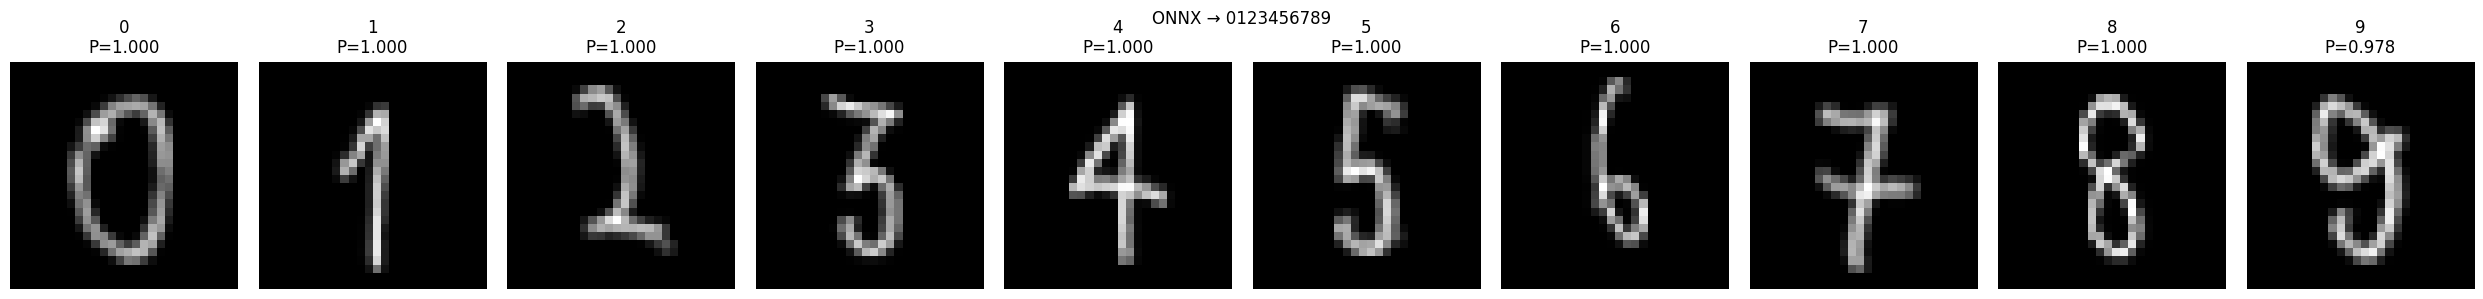


Arquivo: WhatsApp Image 2026-09-18 at 12.24.57 (5).jpeg
Recortes encontrados: 3
Previsões ONNX: [9, 9, 9]
Sequência ONNX: 999


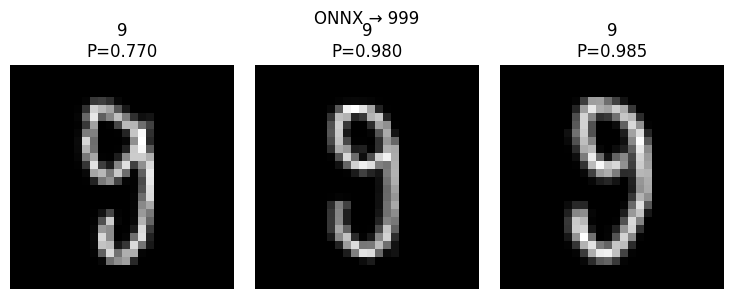


Arquivo: WhatsApp Image 2026-09-18 at 12.24.57 (1) (2).jpeg
Recortes encontrados: 3
Previsões ONNX: [7, 7, 7]
Sequência ONNX: 777


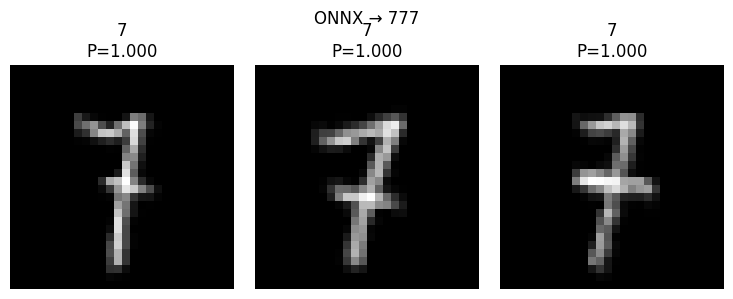


Arquivo: WhatsApp Image 2026-09-18 at 12.24.57 (2) (2).jpeg
Recortes encontrados: 3
Previsões ONNX: [7, 7, 7]
Sequência ONNX: 777


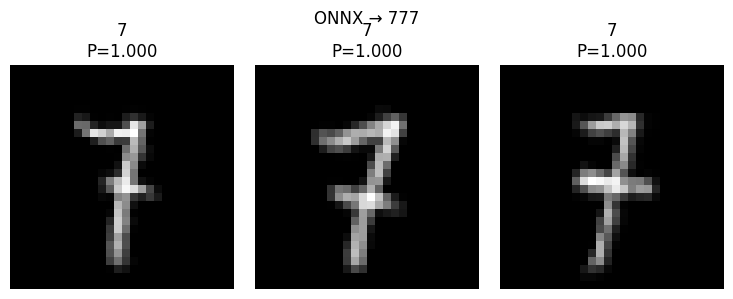


Arquivo: WhatsApp Image 2026-09-18 at 12.24.57 (3) (2).jpeg
Recortes encontrados: 3
Previsões ONNX: [5, 5, 5]
Sequência ONNX: 555


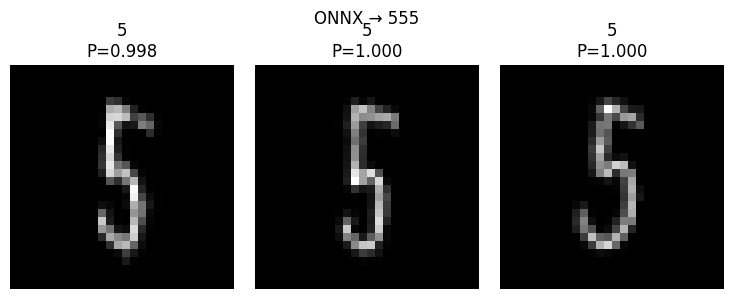

In [ ]:
# ============================================================
# TESTE FINAL — SEQUÊNCIA USANDO O ONNX
# ============================================================

import io
import numpy as np
import onnxruntime as ort
from PIL import Image
from google.colab import files

# ------------------------------------------------------------
# 1. Carregar ONNX já exportado
# ------------------------------------------------------------

caminho_onnx = PASTA / "modelo_digitcheck_sequencia_v2.onnx"

sessao_onnx = ort.InferenceSession(
    str(caminho_onnx),
    providers=["CPUExecutionProvider"]
)

nome_entrada_onnx = sessao_onnx.get_inputs()[0].name

print("✅ ONNX carregado")
print("Entrada:", nome_entrada_onnx)


# ------------------------------------------------------------
# 2. Função para classificar UM recorte com ONNX
# ------------------------------------------------------------

def prever_recorte_onnx(recorte):
    arr = np.asarray(
        recorte,
        dtype=np.float32
    )

    if arr.ndim == 2:
        arr = arr[..., None]

    if arr.shape != (28, 28, 1):
        raise ValueError(
            f"Formato inesperado do recorte: {arr.shape}"
        )

    arr = arr[None, ...]

    saida = sessao_onnx.run(
        None,
        {
            nome_entrada_onnx: arr
        }
    )[0][0]

    digito = int(
        np.argmax(saida)
    )

    probabilidade = float(
        saida[digito]
    )

    return {
        "digito": digito,
        "probabilidade": probabilidade,
        "probabilidades": saida
    }


# ------------------------------------------------------------
# 3. Upload da foto
# ------------------------------------------------------------

enviados = files.upload()

if not enviados:
    raise ValueError(
        "Nenhuma imagem enviada."
    )


# ------------------------------------------------------------
# 4. Testar cada imagem
# ------------------------------------------------------------

for nome, conteudo in enviados.items():

    imagem = Image.open(
        io.BytesIO(conteudo)
    )

    # Usa a MESMA segmentação da Etapa 17
    analise = analisar_foto(
        imagem,
        modo="sequencia",
        rotacao=0,
        roi=None,
        quantidade_esperada=None
    )

    extracao_onnx = analise["extracao"]

    recortes = extracao_onnx["recortes"]

    if not recortes:
        print(
            f"❌ {nome}: nenhum dígito segmentado."
        )
        continue

    previsoes_onnx = []

    for recorte in recortes:
        previsao = prever_recorte_onnx(
            recorte
        )

        previsoes_onnx.append(
            previsao
        )

    digitos = [
        p["digito"]
        for p in previsoes_onnx
    ]

    sequencia = "".join(
        str(d)
        for d in digitos
    )

    print()
    print("=" * 50)
    print("Arquivo:", nome)
    print("Recortes encontrados:", len(recortes))
    print("Previsões ONNX:", digitos)
    print("Sequência ONNX:", sequencia)
    print("=" * 50)

    # --------------------------------------------------------
    # 5. Mostrar recortes
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        len(recortes),
        figsize=(
            max(3, len(recortes) * 2.5),
            3
        )
    )

    if len(recortes) == 1:
        axes = [axes]

    for ax, recorte, previsao in zip(
        axes,
        recortes,
        previsoes_onnx
    ):
        ax.imshow(
            recorte,
            cmap="gray"
        )

        ax.axis("off")

        ax.set_title(
            f'{previsao["digito"]}\n'
            f'P={previsao["probabilidade"]:.3f}'
        )

    plt.suptitle(
        f"ONNX → {sequencia}"
    )

    plt.tight_layout()
    plt.show()

## 20 — Como interpretar o resultado

O projeto deve responder quatro perguntas diferentes:

1. **Segmentação:** a fotografia produziu o recorte correto?
2. **Classificação:** dado um recorte correto, qual dígito a CNN encontrou?
3. **Rejeição:** o sistema soube pedir revisão quando havia dúvida?
4. **Fim a fim:** a resposta final da fotografia estava correta?

### Critérios de avanço

Antes de começar operadores e expressões algébricas, procure atingir no conjunto real de teste:

- pelo menos 90% de segmentação válida;
- pelo menos 95% de acurácia condicional em recortes reais;
- pelo menos 85% de acurácia bruta fim a fim;
- alta acurácia entre previsões aceitas;
- exemplos de erro documentados por causa: iluminação, orientação, fragmentação ou confusão de classe.

### Próxima evolução

Somente depois de estabilizar `um_digito`, aperfeiçoe `sequencia`. A futura leitura de expressões algébricas poderá reaproveitar o classificador e a segmentação, acrescentando operadores, organização espacial e um interpretador simbólico como o SymPy.